In [1]:
import sys, os, pickle, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu, kruskal, fisher_exact
from statsmodels.stats.multitest import multipletests

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from spk_lfp_cluster_comp_analysis import *
from spk_feat_cluster_comp_analysis import compile_experiment_results
from config import SPE1_PICKLE_ROOT, PRIORITY_CELLS, CELL_IDS, DICT_CELL_TYPE, DICT_PATCH_TYPE, DICT_CORT_DEPTH, DICT_DARK_NEURONS, DICT_EAP_WAV

warnings.filterwarnings("ignore")
import os


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
SLIDING_DIR  = os.path.join(SPE1_PICKLE_ROOT, "lfp_spk_group_pickles")
PREPOST_DIR  = os.path.join(SPE1_PICKLE_ROOT, "prepost_specparam_pickles")
CLUSTER_DIR  = os.path.join(SPE1_PICKLE_ROOT, "cluster_pickles")

# ── Cell subsets ───────────────────────────────────────────────────────────────
subsets = get_cell_subsets(PRIORITY_CELLS, CELL_IDS)
SUBSET_LABELS = [
    ("Priority cells",      subsets["priority"]),
    ("Non-priority cells",  subsets["np"]),
    ("All cells combined",  subsets["all"]),
]
print(f"Priority: {len(subsets['priority'])} | NP: {len(subsets['np'])} | All: {len(subsets['all'])}")

# ── Feature type definitions ───────────────────────────────────────────────────
# Numerical LFP features (effect sizes, continuous)
# Sliding window uses label strings; prepost uses feature keys
LFP_NUMERICAL = ["Aperiodic Exponent", "r-squared",
                  "Theta AUC", "Gamma AUC", "LFP Mean Amplitude"]
LFP_NUMERICAL_PREPOST = ["exponent", "r_squared", "band_aucs.theta",
                          "band_aucs.gamma", "lfp_mean"]

# Spike feature colours
feature_shades = {
    'peak_amp_cluster':         '#8c564b',
    'peak_sharpness_cluster':   '#a06d62',
    'peak_width_cluster':       '#b38479',
    'exp_lambda_cluster':       '#c561a8',
    'inflection_time_cluster':  '#9b59b6',
    'exp_const_cluster':        '#d7aee0',
    'log_isi_cluster':          '#7f7f7f',
    'spk_times_ms_cluster':     '#b0b0b0',
}

# Module-level constants (not exported by import *)
_CB_PALETTE = ['#0072B2', '#D55E00', '#009E73', '#CC79A7',
               '#56B4E9', '#E69F00', '#F0E442', '#000000']
_SIG_COL    = '#D55E00'
_INSIG_COL  = '#56B4E9'
_FS_SM, _FS_AX, _FS_SUB, _FS_TTL = 11, 13, 14, 16


Priority: 7 | NP: 36 | All: 43


In [ ]:
# ── Run-control flags ─────────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles


## Load data

Sliding window stats + pre/post stats + all cell metadata from config.

**Categorical**: cell type (PC/IN), recording type (Juxta/WC), clamp mode (IC/VC), dark neuron (yes/no), EAP visible (yes/no)
**Numerical**: cortical depth (µm)

In [3]:
df_pop_stats, pop_traces = compile_lfp_stats(SLIDING_DIR)
df_prepost               = compile_prepost_stats(PREPOST_DIR)

df_meta = build_cell_lfp_metadata(
    df_pop_stats, LFP_NUMERICAL,
    dict_cell_type   = DICT_CELL_TYPE,
    dict_patch_type  = DICT_PATCH_TYPE,
    dict_cort_depth  = DICT_CORT_DEPTH,
    dict_dark_neurons= DICT_DARK_NEURONS,
    dict_eap_wav     = DICT_EAP_WAV,
)

CAT_VARS = ["cell_type", "recording_type", "clamp_mode", "dark_neuron", "eap_visible"]
NUM_VARS = ["cort_depth"]

print(f"Cells with LFP data: {df_meta['cell_id'].nunique()}")
print(df_meta.groupby("cell_type")["cell_id"].nunique().rename("n_cells"))

Cells with LFP data: 36
cell_type
IN     4
PC    32
Name: n_cells, dtype: int64


## Metadata × LFP effect strength

Does any cell-level property predict how strongly LFP is coupled to spike waveform clusters?

Categorical variables: Kruskal-Wallis + BH-FDR. Bootstrap 95% CI on group medians shown as error bars. Stars/ns always labelled.

Cortical depth: Spearman ρ + bootstrap 95% CI (n=2000) + BH-FDR.


Priority cells (n=7)


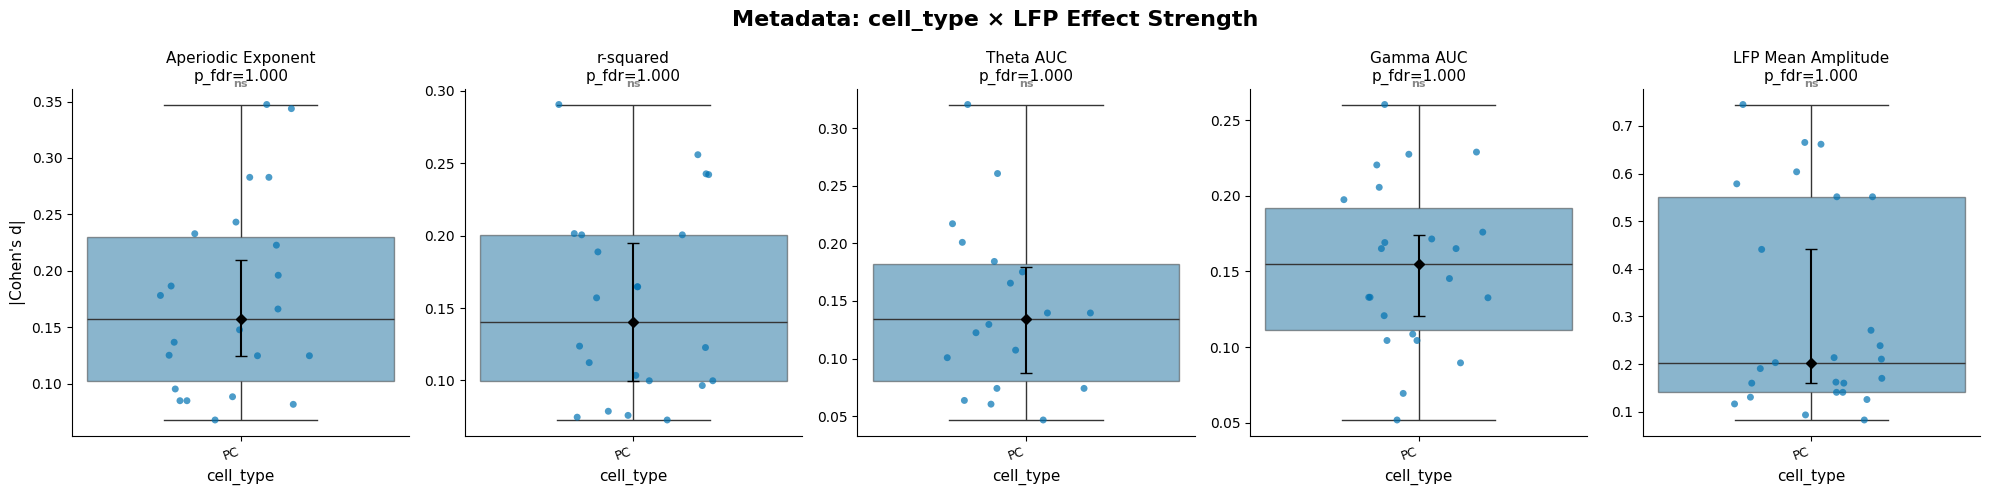

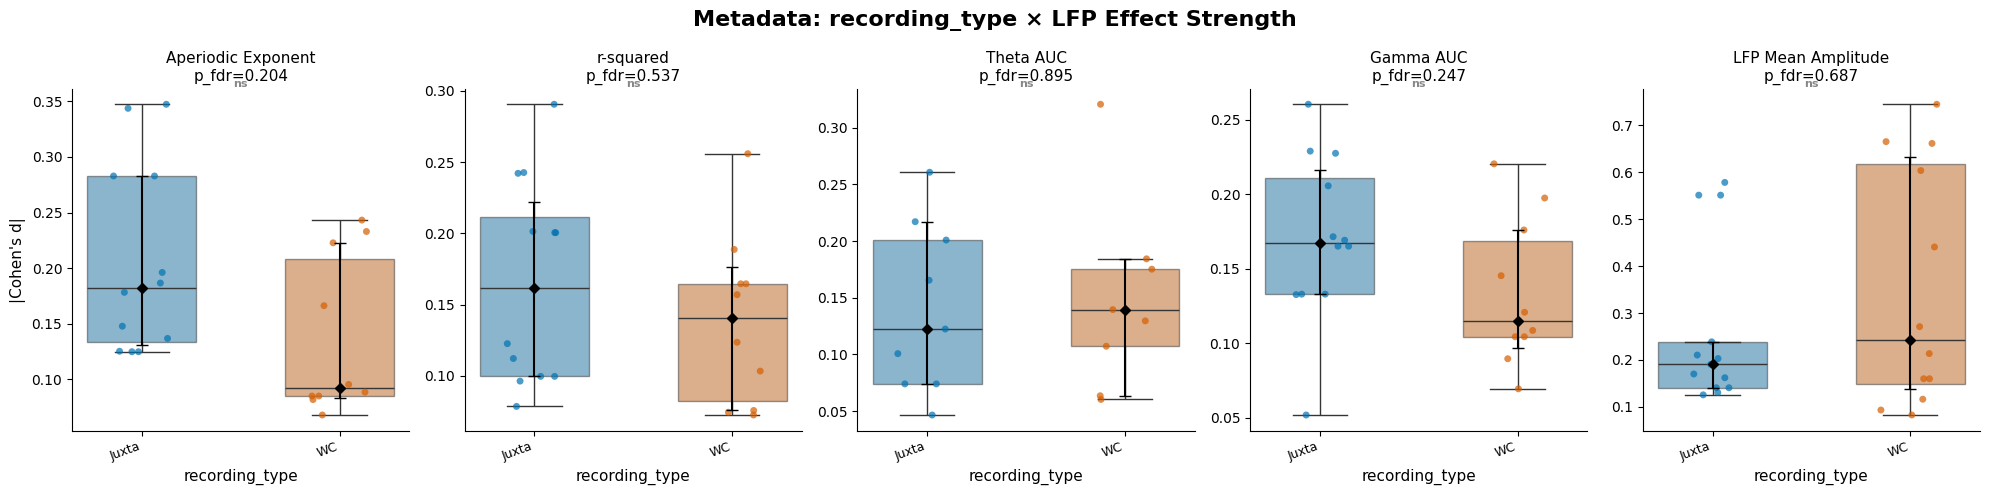

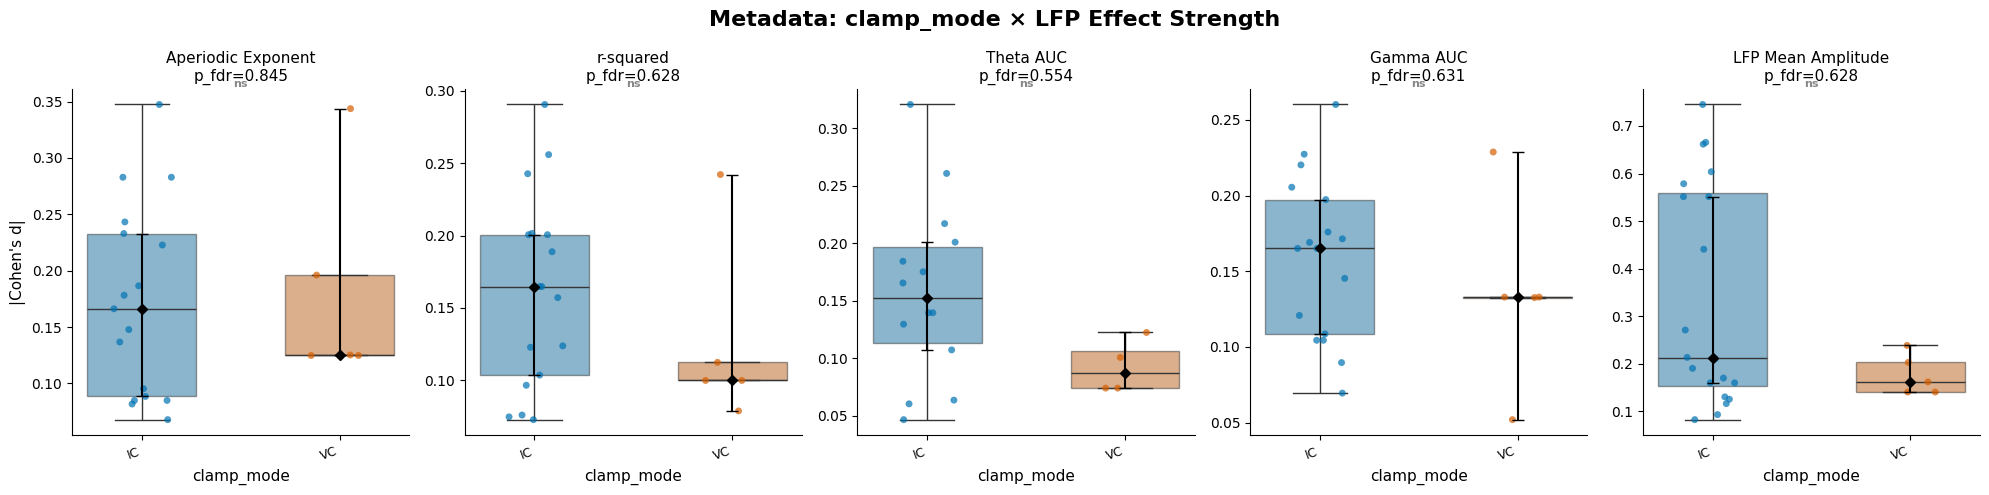

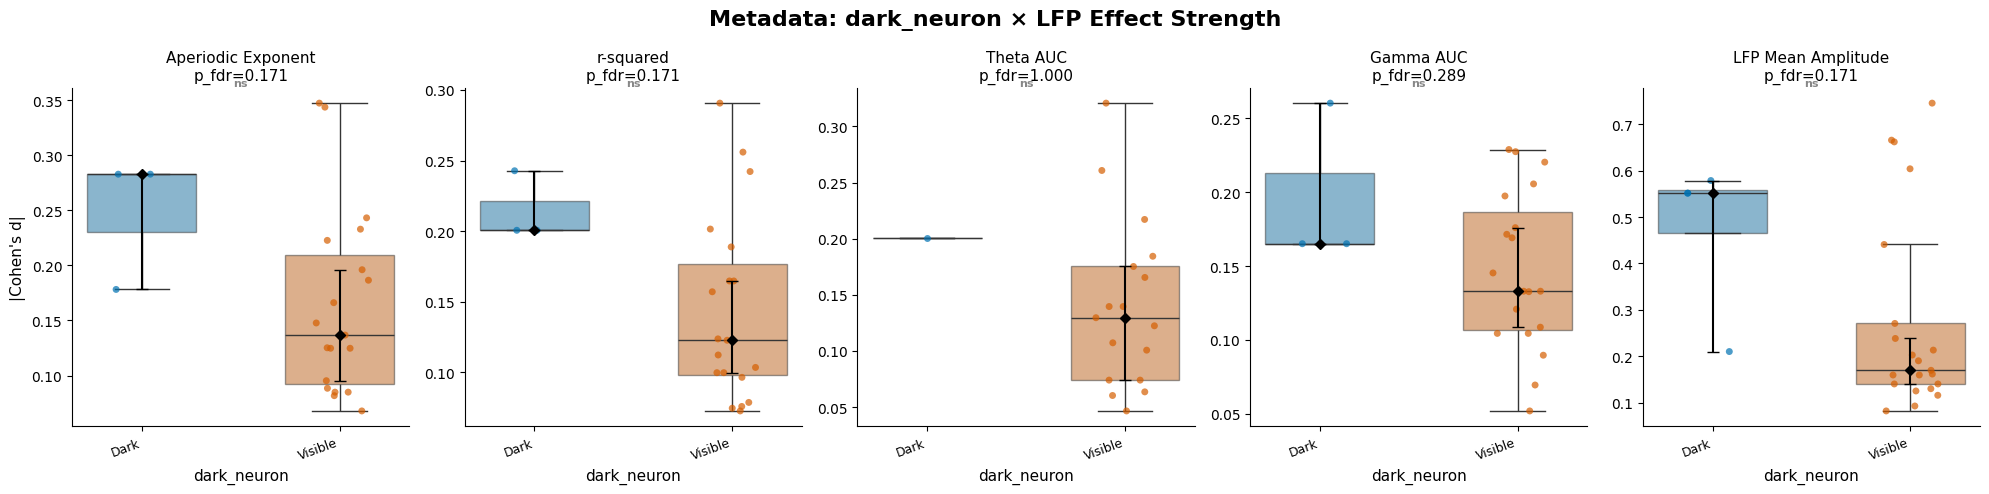

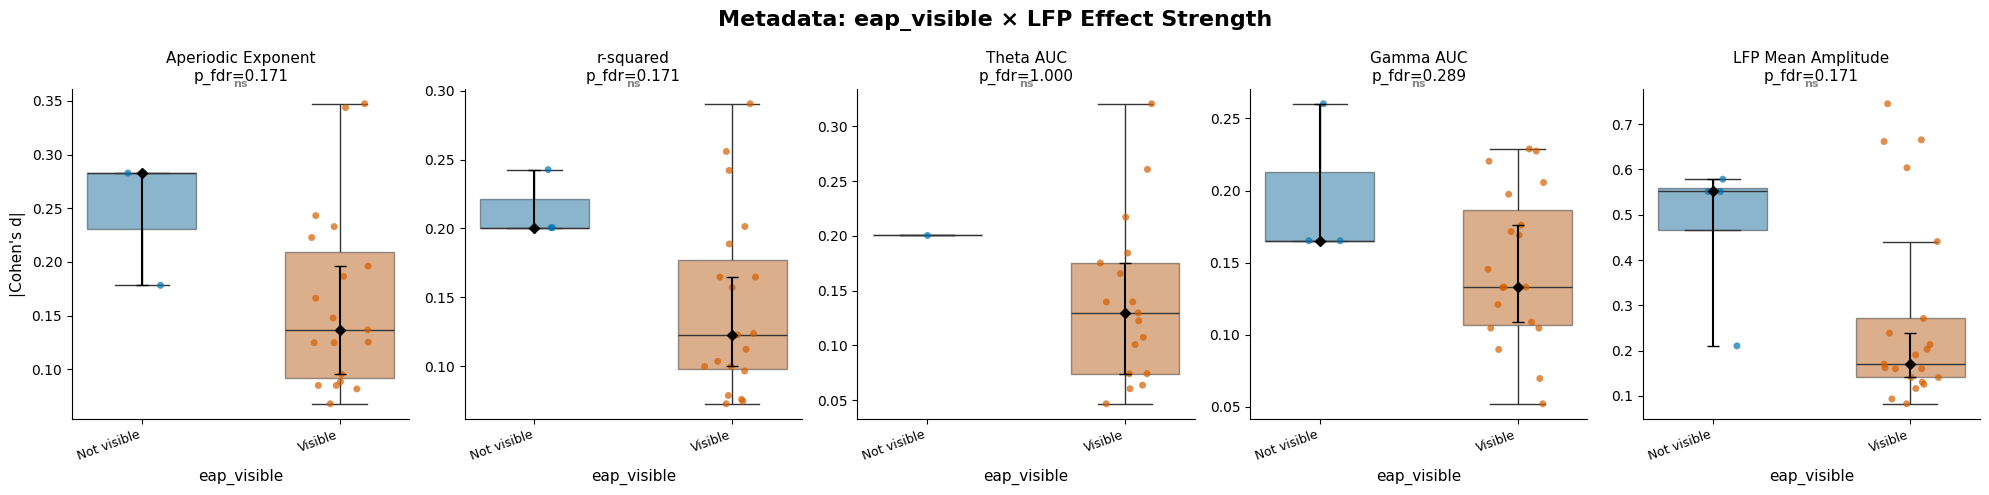

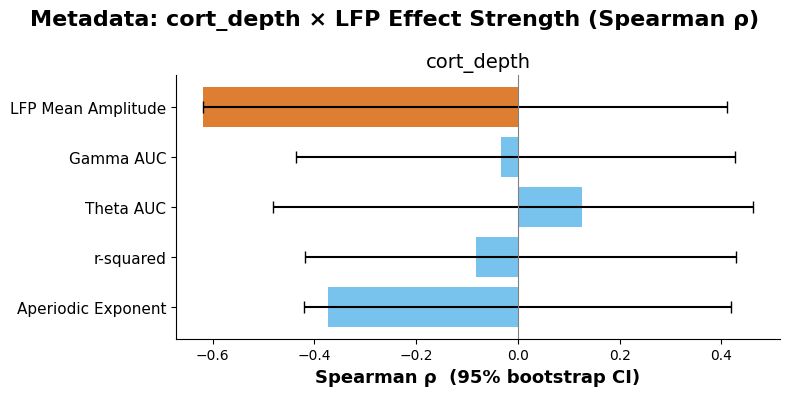


Non-priority cells (n=36)


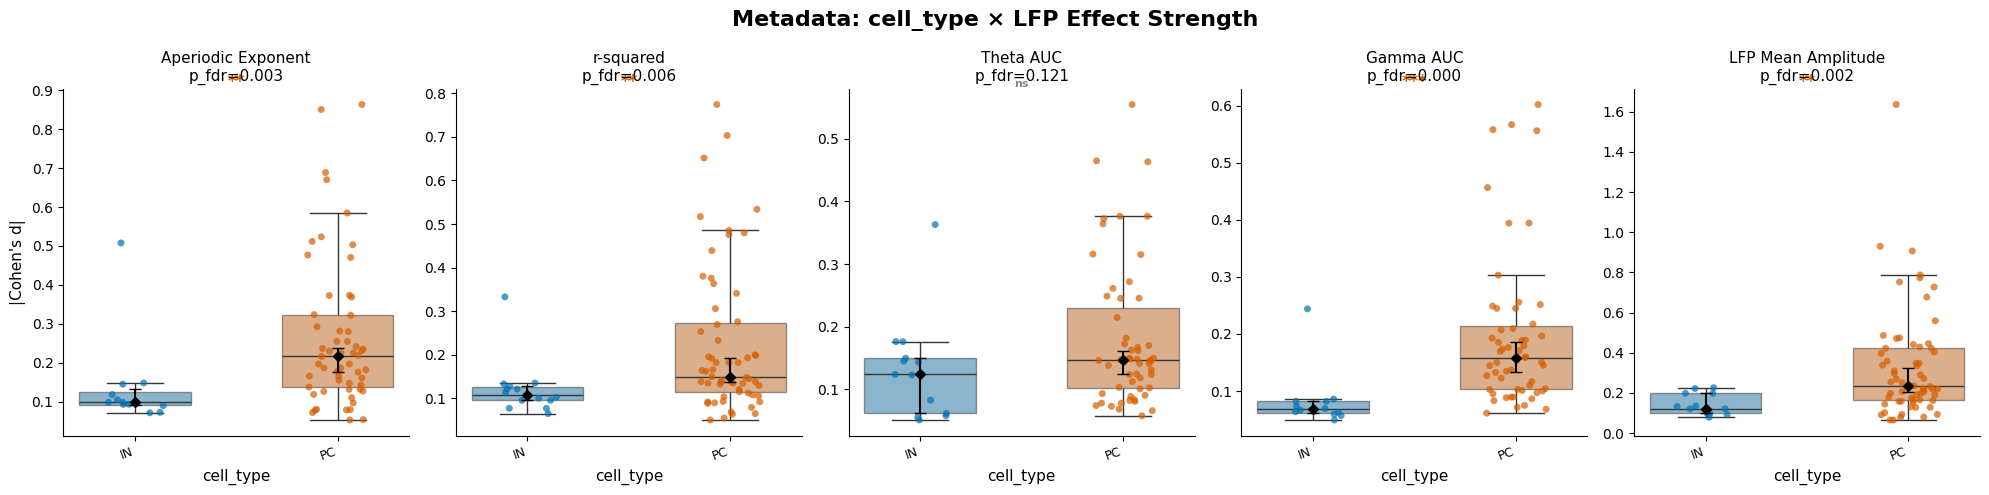

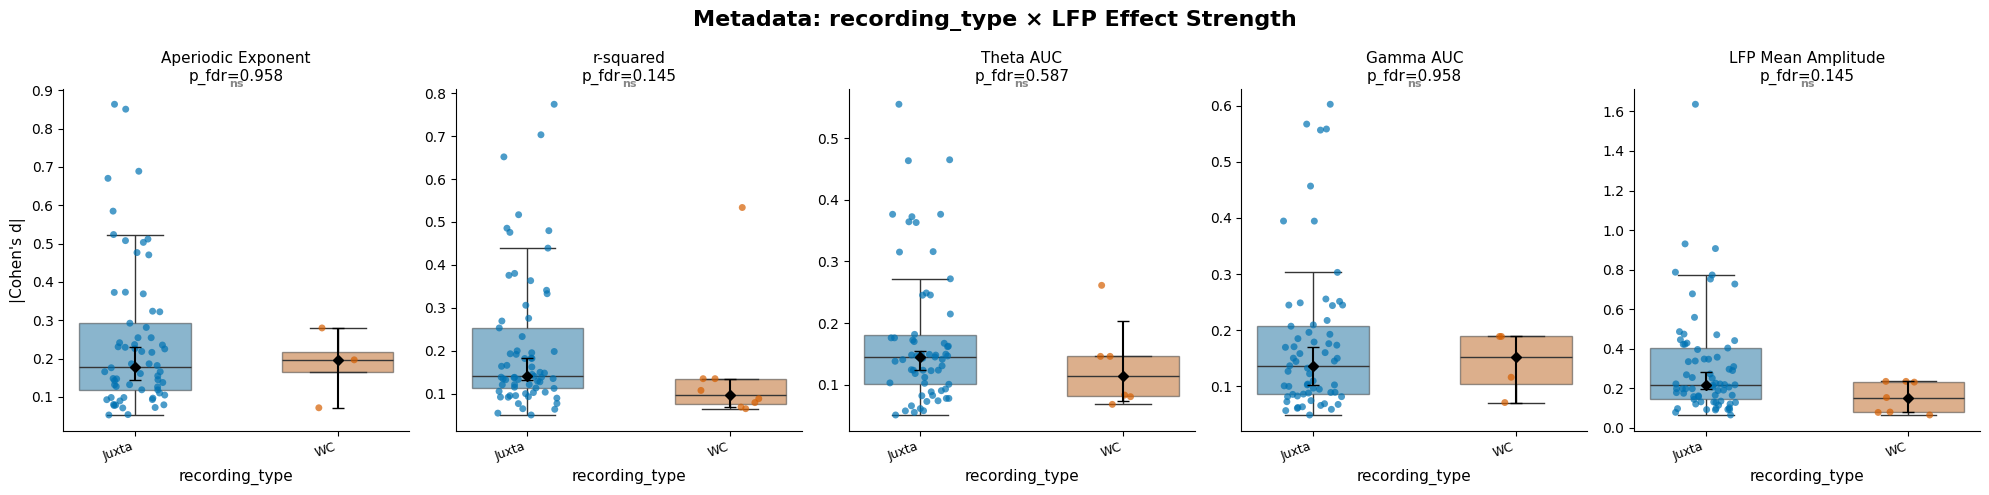

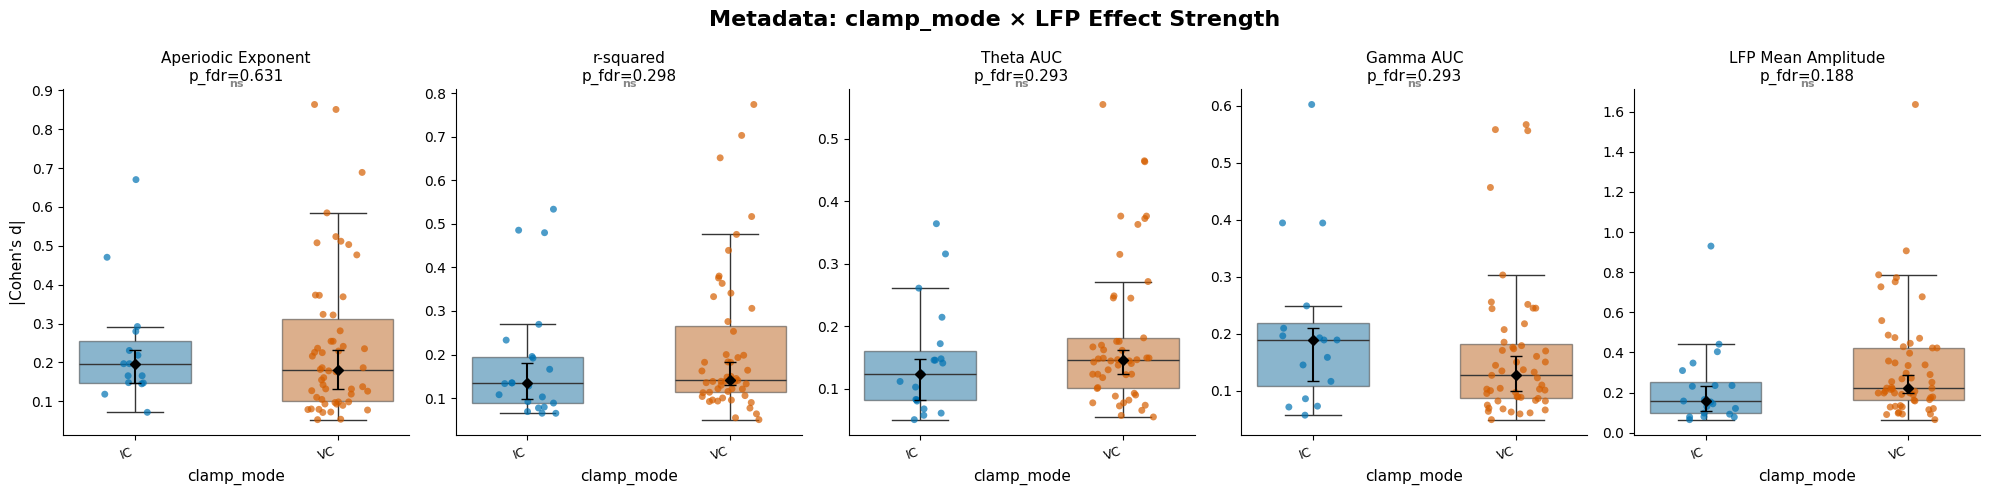

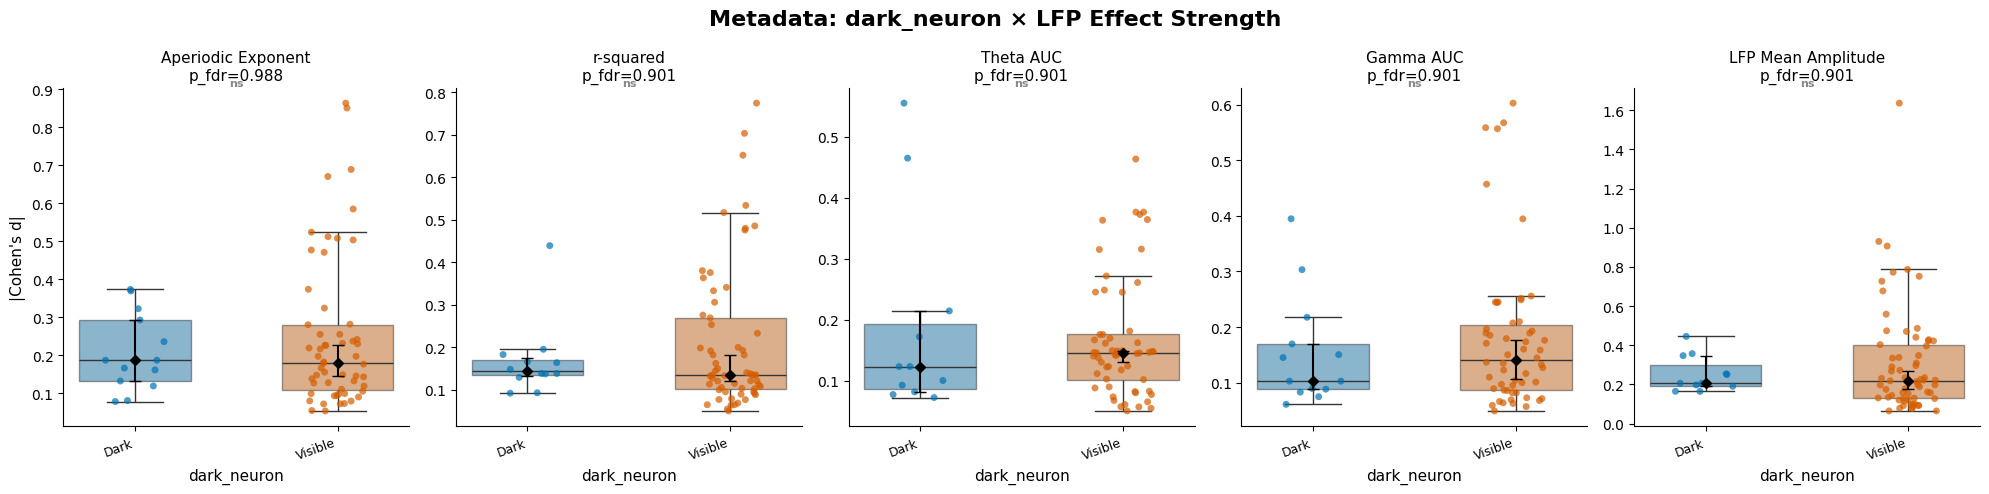

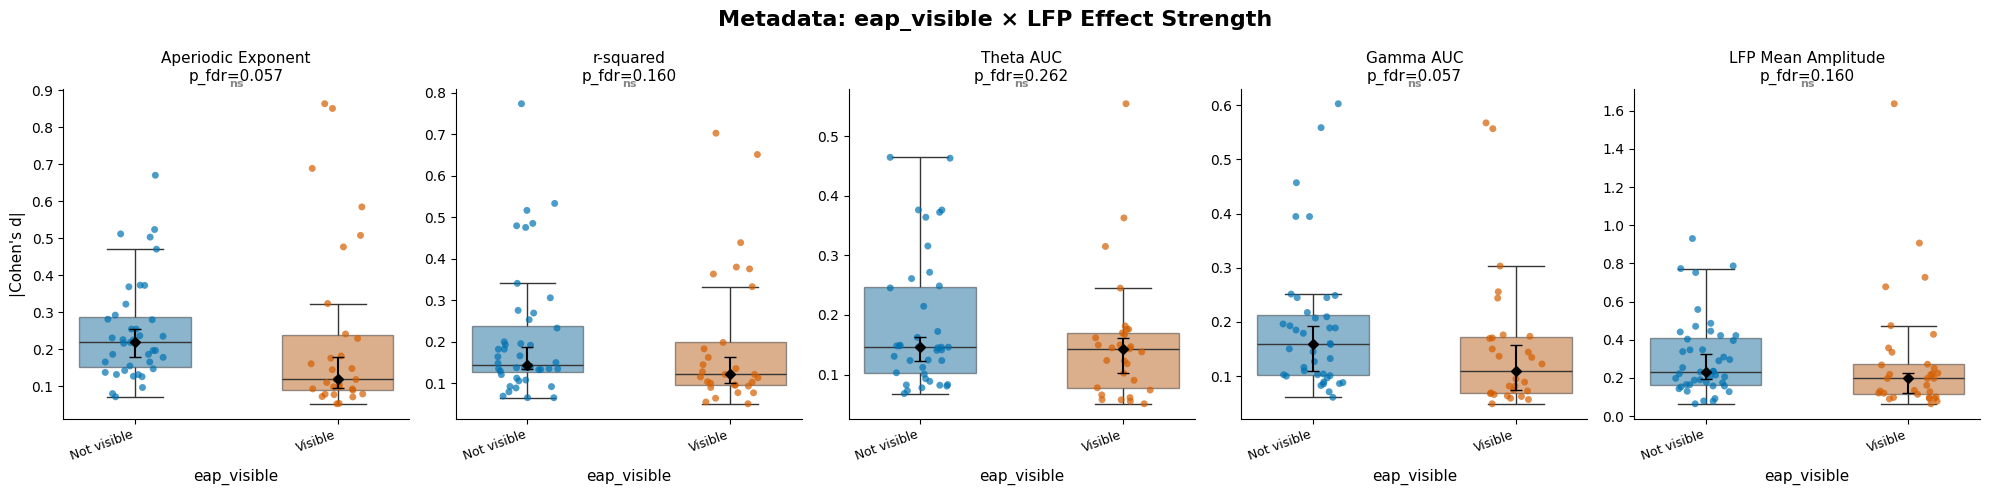

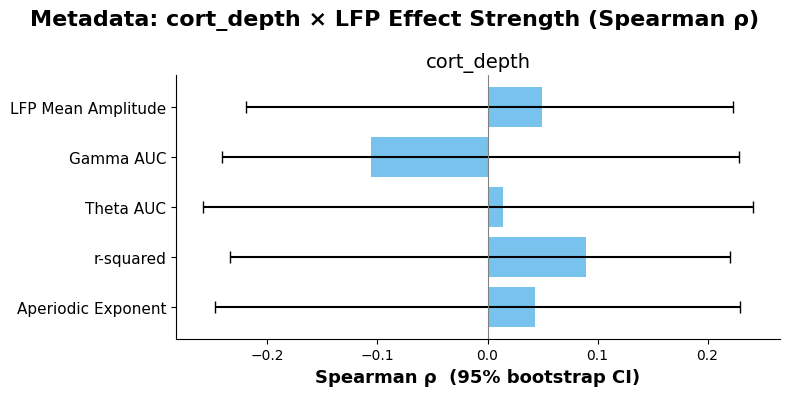


All cells combined (n=43)


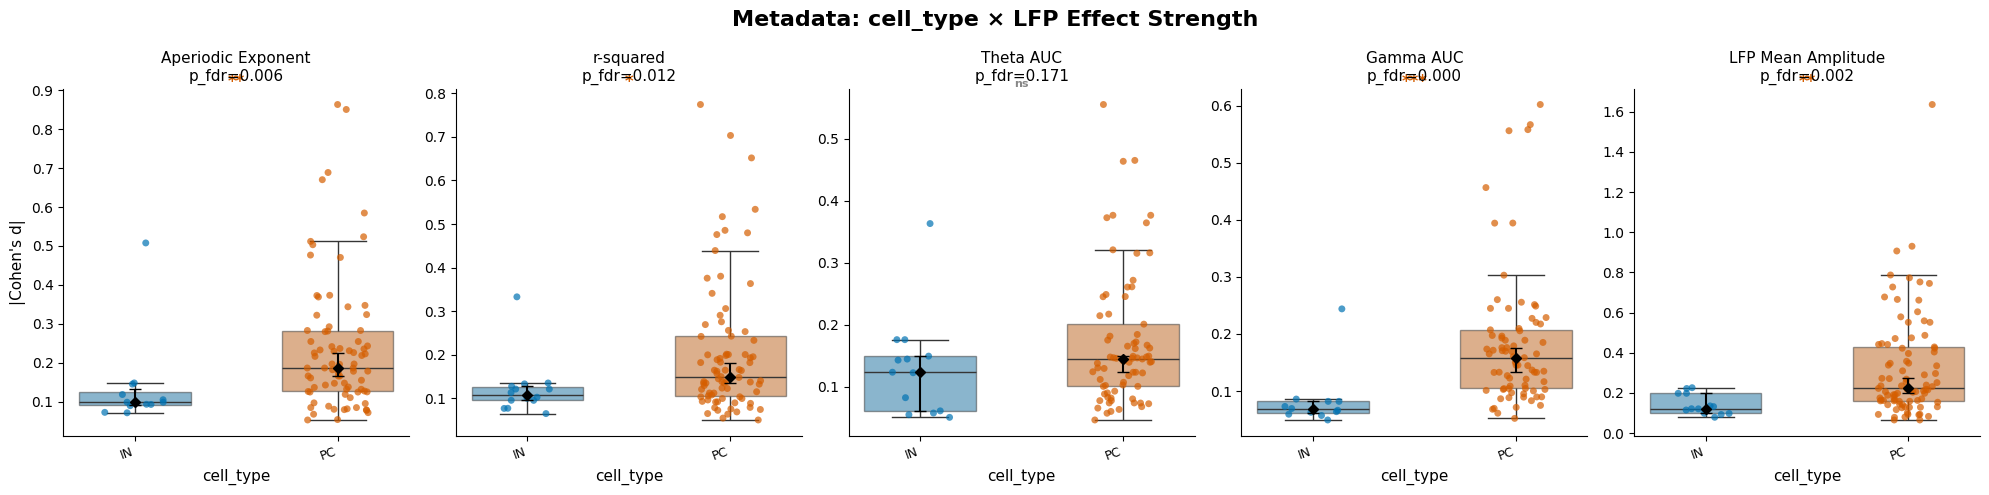

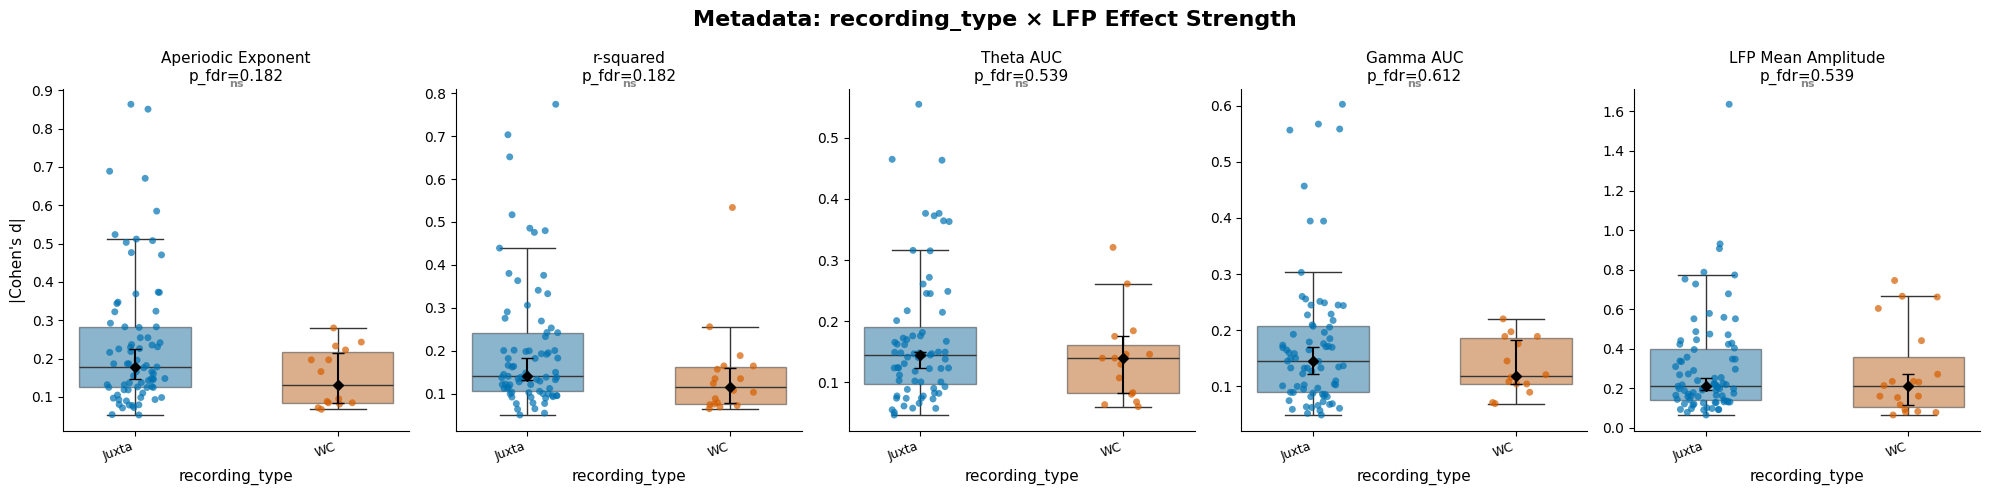

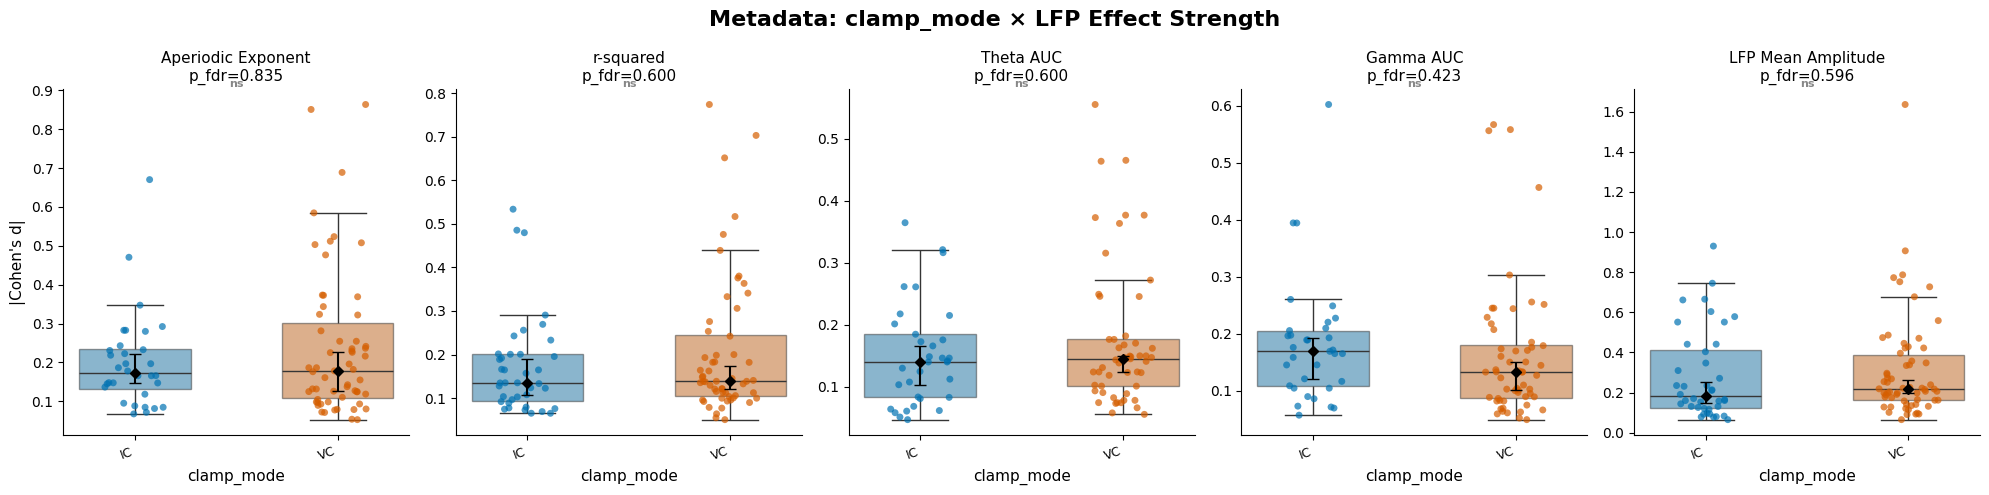

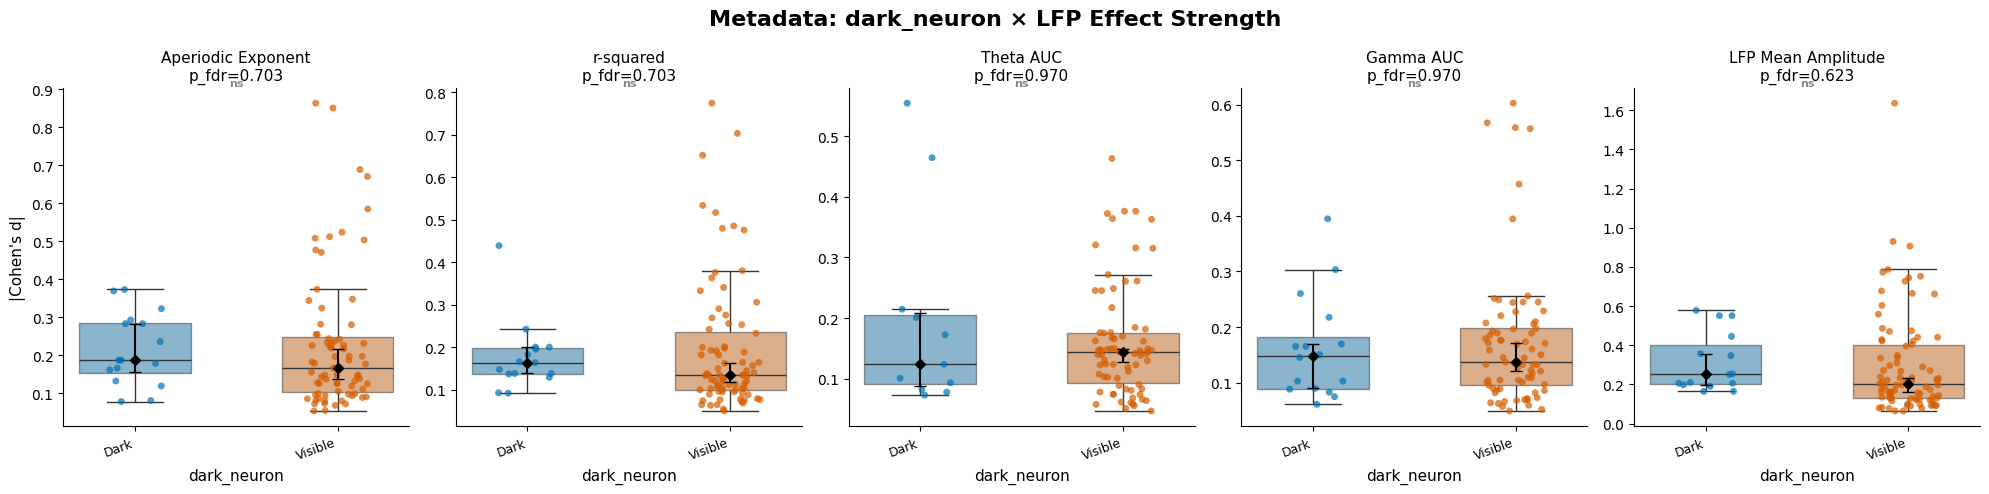

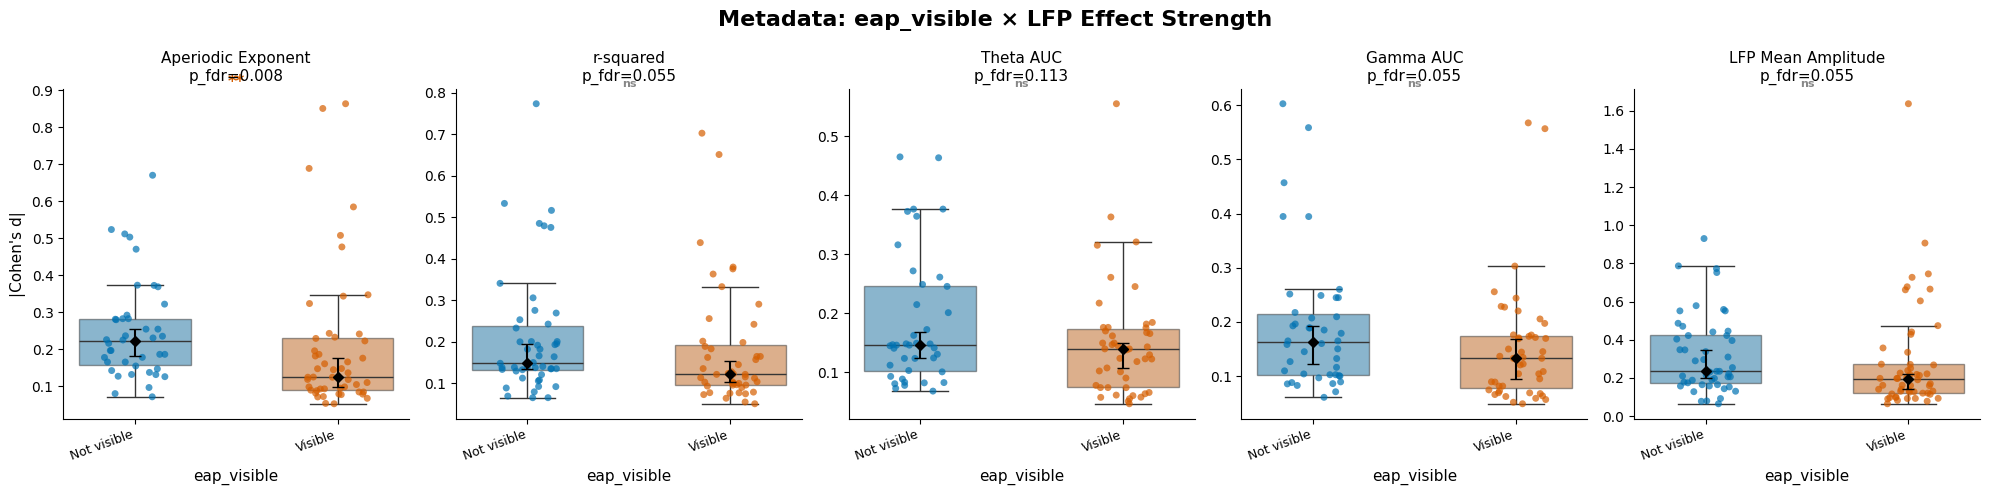

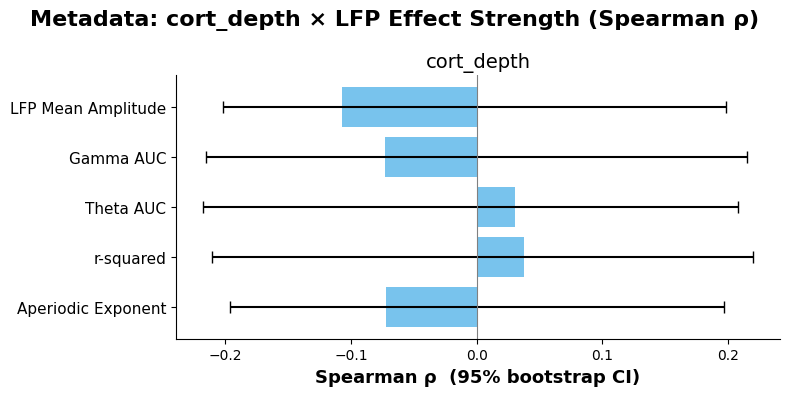

In [4]:
for label, cell_ids in SUBSET_LABELS:
    print(f"\n{'='*60}\n{label} (n={len(cell_ids)})\n{'='*60}")
    df_sub = df_meta[df_meta["cell_id"].isin(cell_ids)]
    if df_sub.empty: continue
    plot_metadata_x_lfp(df_sub, CAT_VARS, NUM_VARS, LFP_NUMERICAL)

If any metadata variable predicts LFP effect strength, it's a potential confound or mechanistic clue. Cell type (PC vs IN) differences would suggest the coupling is cell-type specific. Recording modality differences (Juxta vs WC) would be a confound to address. Dark neuron or EAP visibility effects would suggest the effect is tied to how visible the cell is extracellularly. Depth effects would point to cortical-layer organisation. ns everywhere = LFP coupling is a general property not explained by these coarse descriptors.

## Metadata × LFP × spike feature (3-way)

The sliding window showed near-universal LFP coupling but heterogeneous direction. Does metadata explain which cells go which way?

Kruskal-Wallis on effect size per (LFP × spike) combo per metadata variable, BH-FDR corrected. Significant combinations plotted individually.


Priority cells (n=7)
  --- cell_type ---


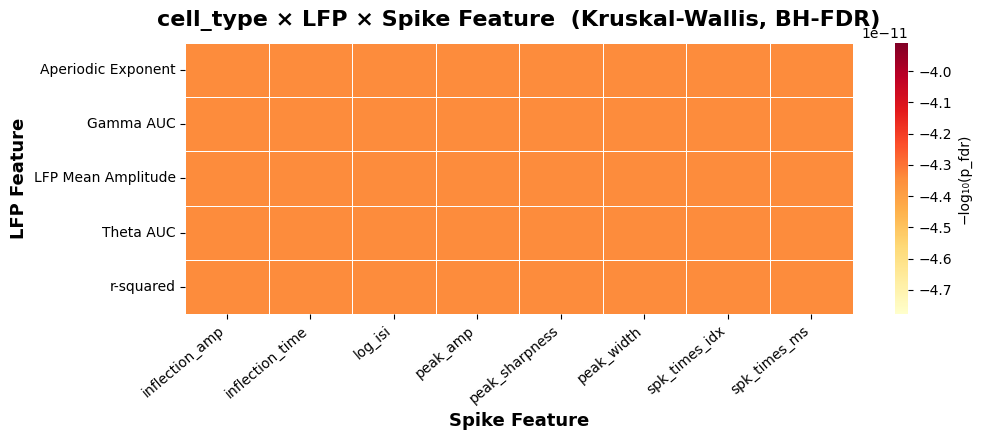

  --- recording_type ---


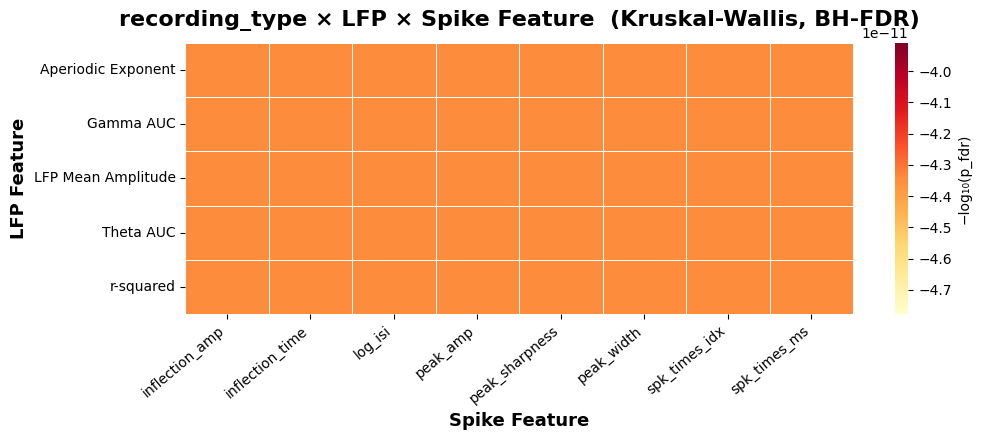

  --- clamp_mode ---


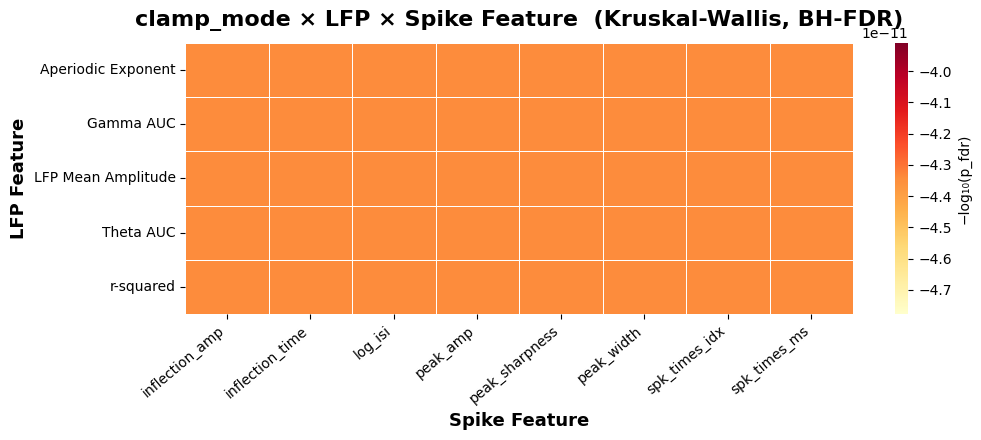

  --- dark_neuron ---


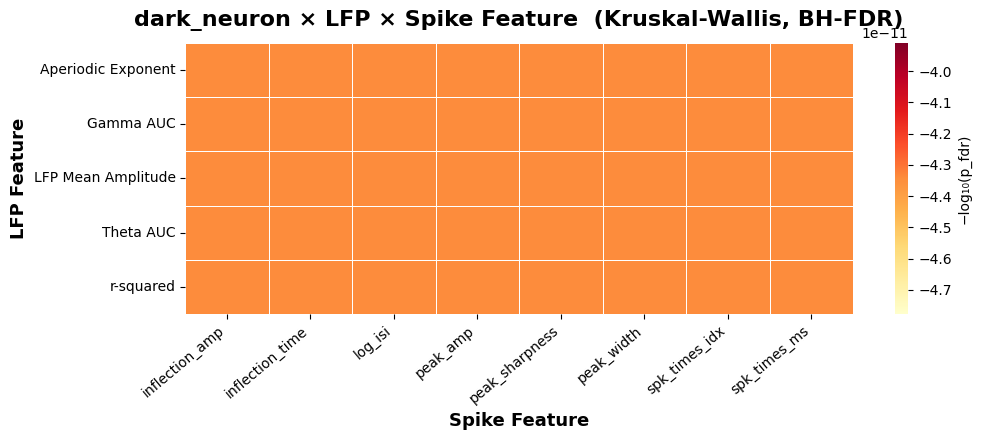

  --- eap_visible ---


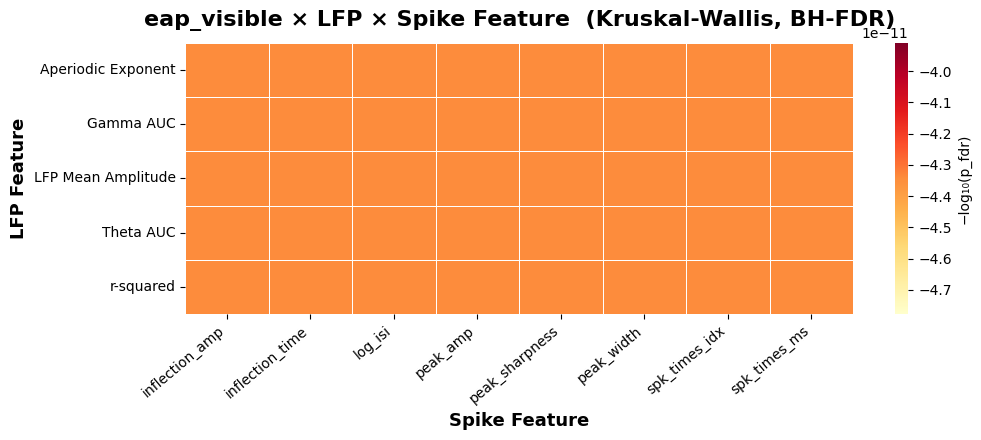


Non-priority cells (n=36)
  --- cell_type ---


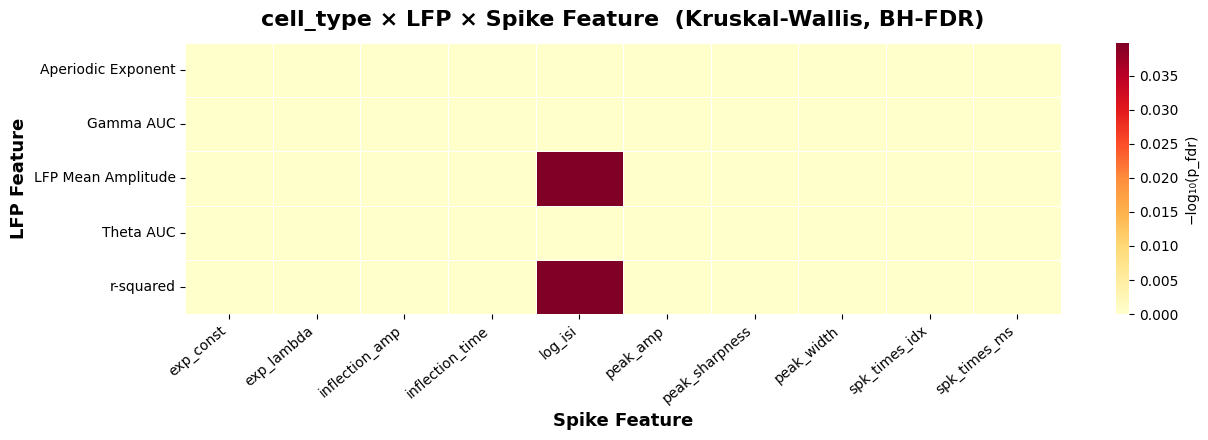

  --- recording_type ---


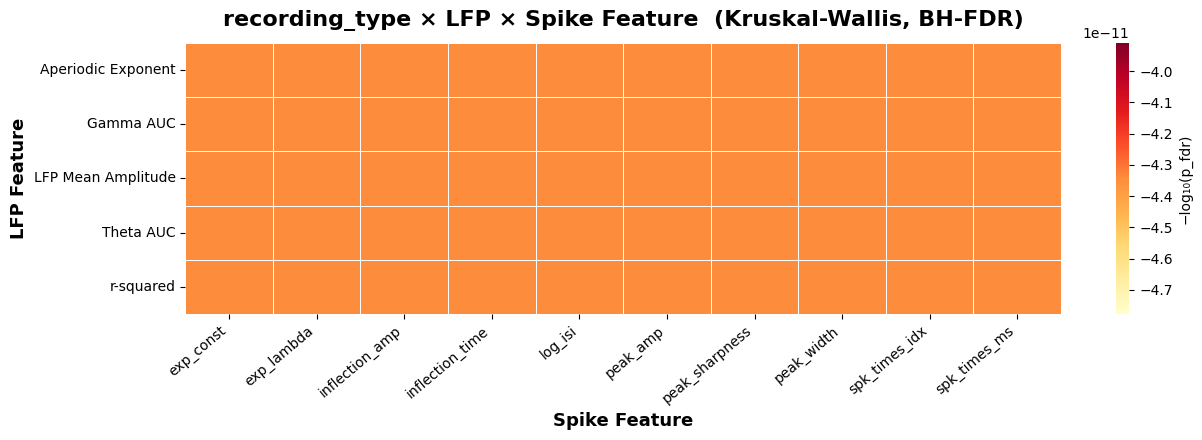

  --- clamp_mode ---


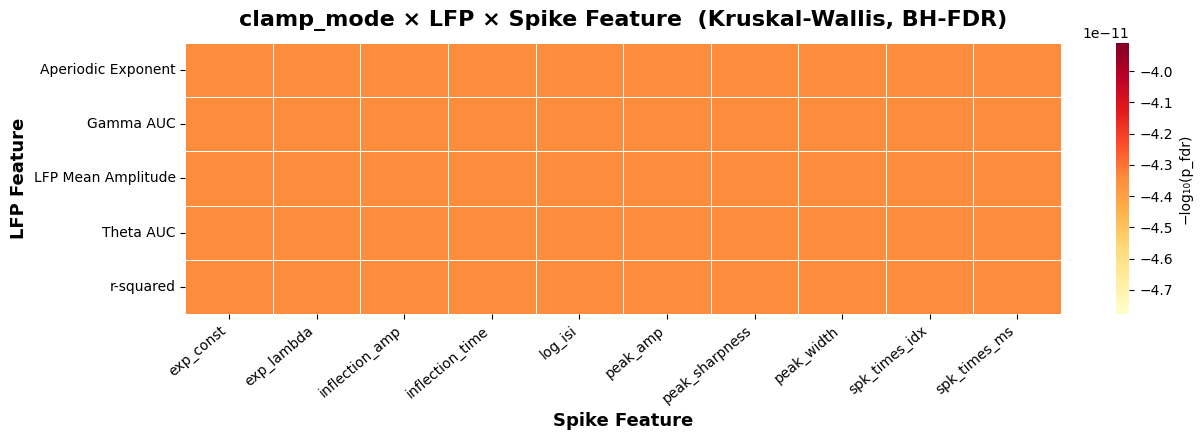

  --- dark_neuron ---


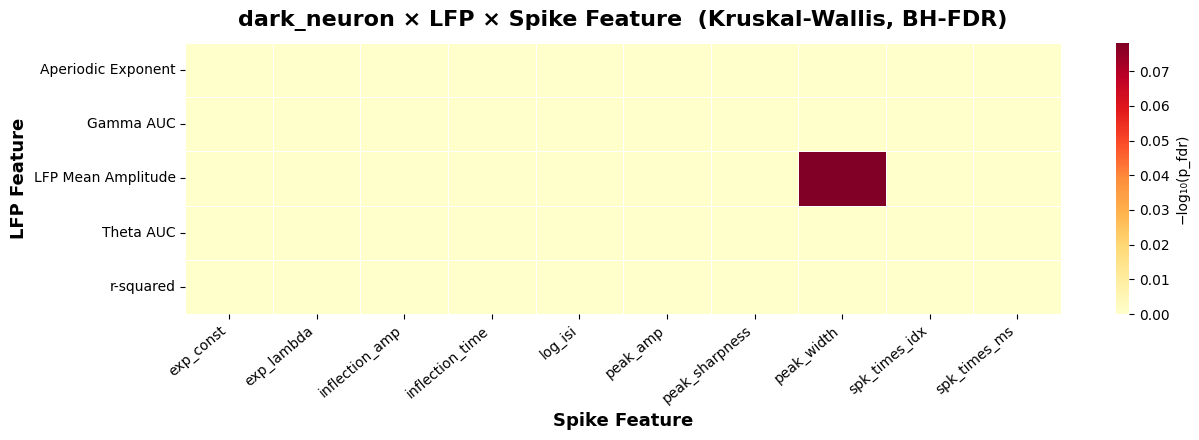

  --- eap_visible ---


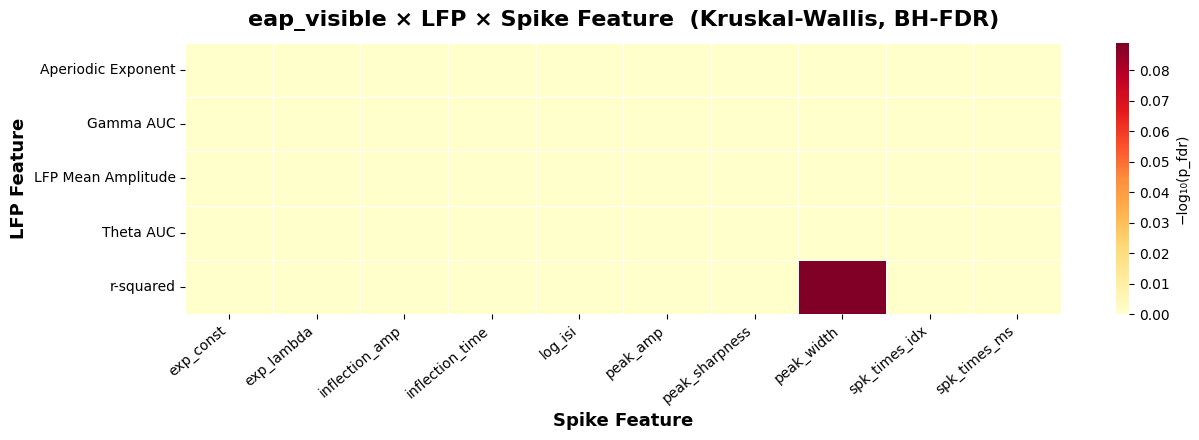


All cells combined (n=43)
  --- cell_type ---


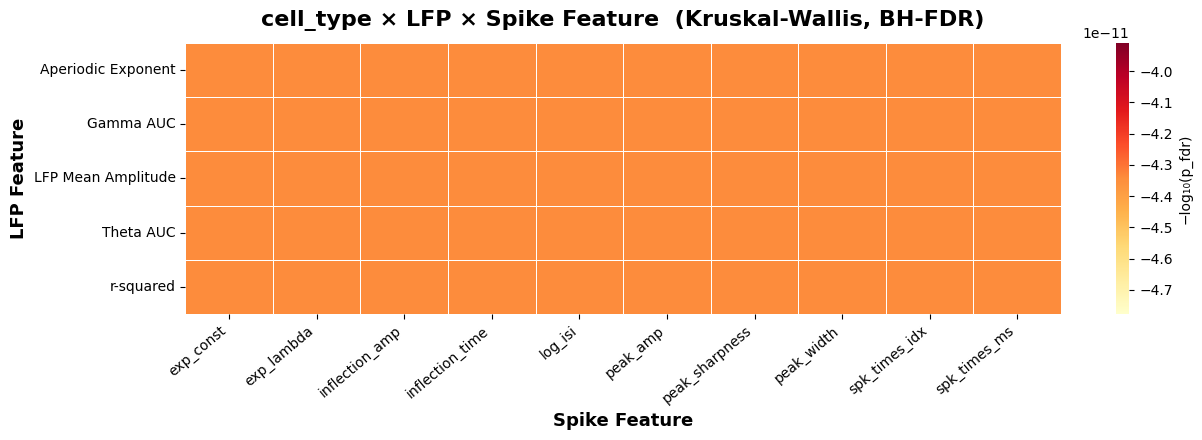

  --- recording_type ---


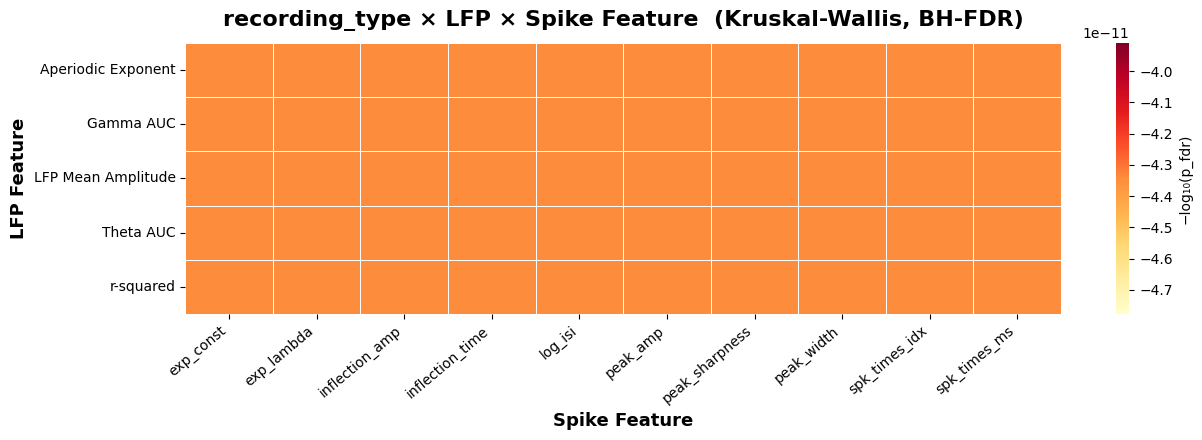

  --- clamp_mode ---


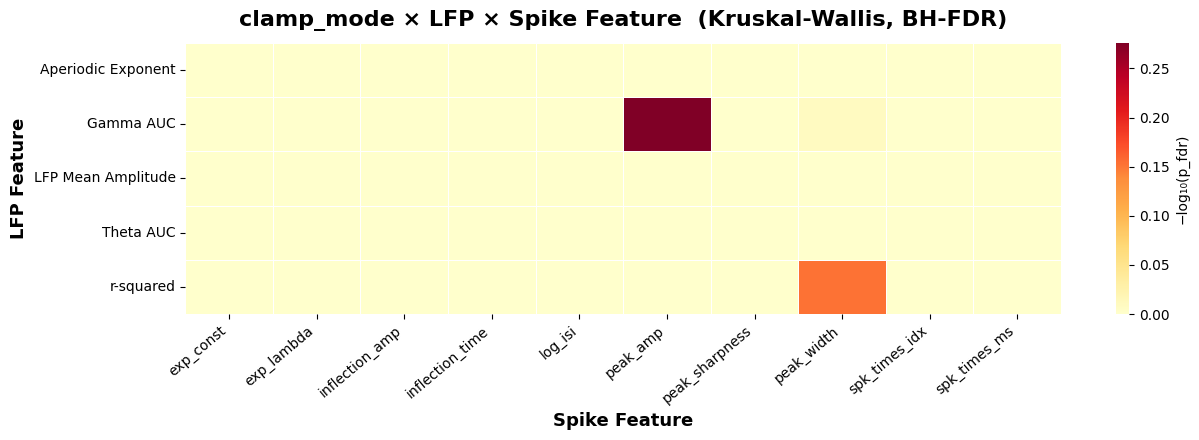

  --- dark_neuron ---


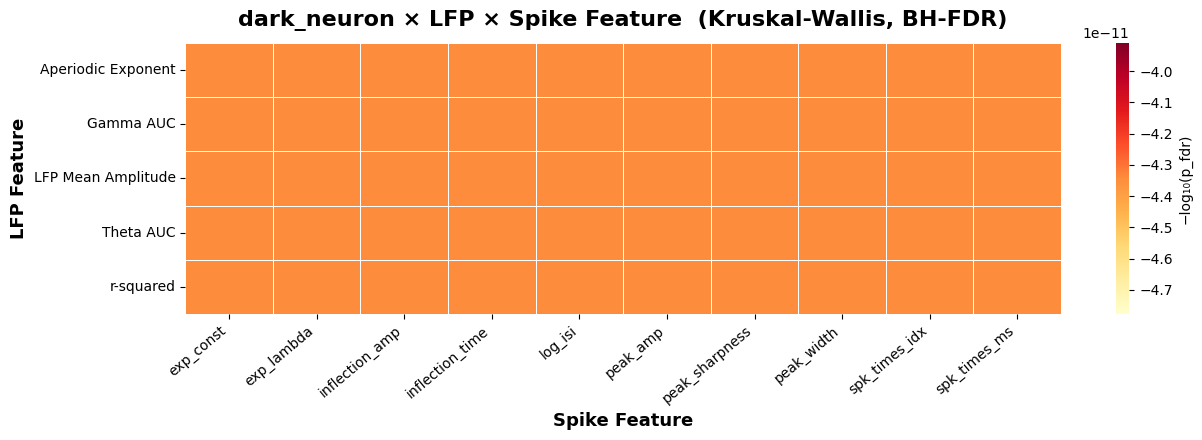

  --- eap_visible ---


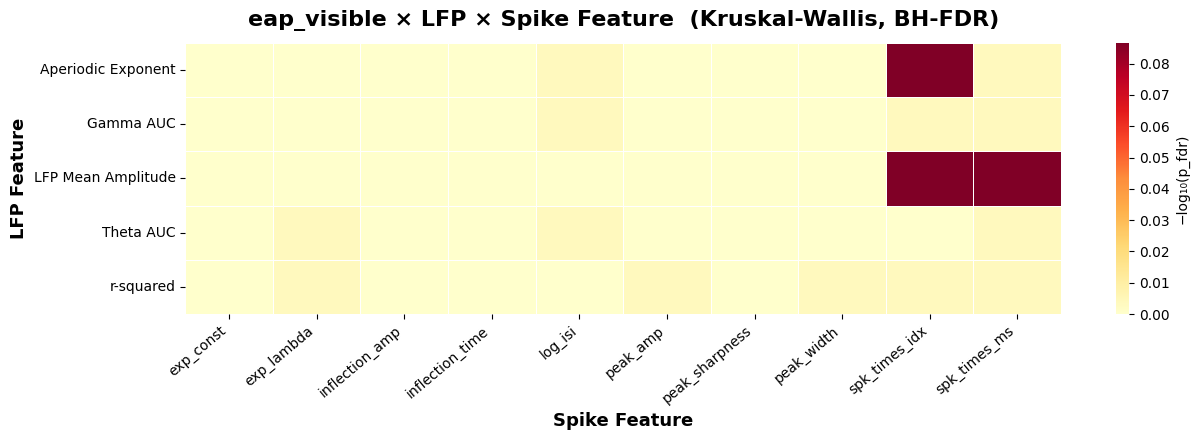

In [5]:
for label, cell_ids in SUBSET_LABELS:
    print(f"\n{'='*60}\n{label} (n={len(cell_ids)})\n{'='*60}")
    df_sub = df_meta[df_meta["cell_id"].isin(cell_ids)]
    df_ps  = df_pop_stats[df_pop_stats["cell_id"].isin(cell_ids)]
    for cat in CAT_VARS:
        print(f"  --- {cat} ---")
        plot_metadata_x_lfp_x_spike(df_sub, df_ps, cat, LFP_NUMERICAL, feature_shades)

A significant 3-way result means the LFP-spike coupling depends on which type of cell you're recording from. For example, if PCs show positive log_ISI × LFP amplitude coupling while INs show negative — that directly explains the heterogeneous direction in the grand averages. ns everywhere means the directionality is cell-idiosyncratic and not captured by any of these metadata variables.

## What predicts LFP effect direction?

For the strongest (LFP × spike) combinations from the sliding window — LFP Mean Amplitude and Aperiodic Exponent × log_ISI — show the **signed** Cohen's d broken down by all metadata variables.

Positive d = high cluster occurs when LFP is higher. Negative = lower. Bootstrap 95% CI on median + Mann-Whitney/Kruskal-Wallis. Stars/ns always shown.


Priority cells (n=7)


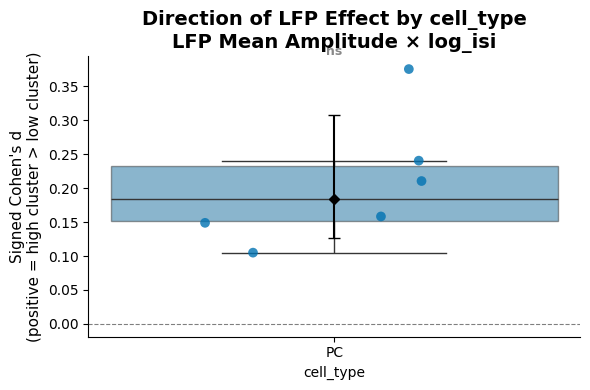

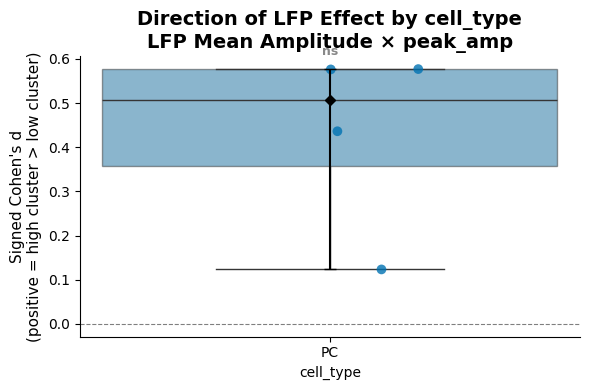

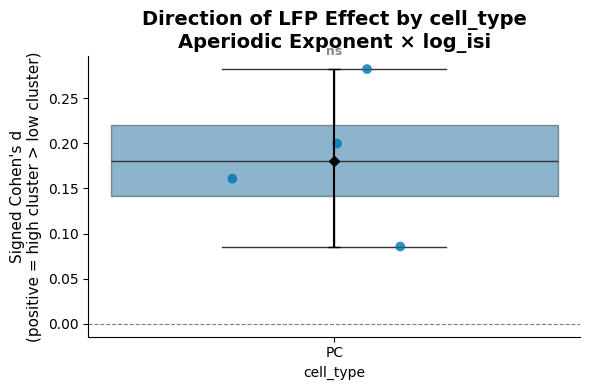

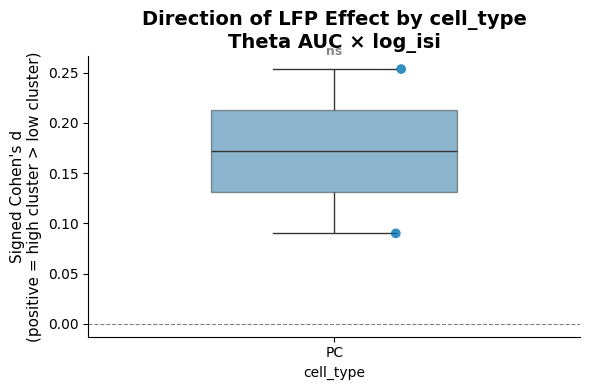

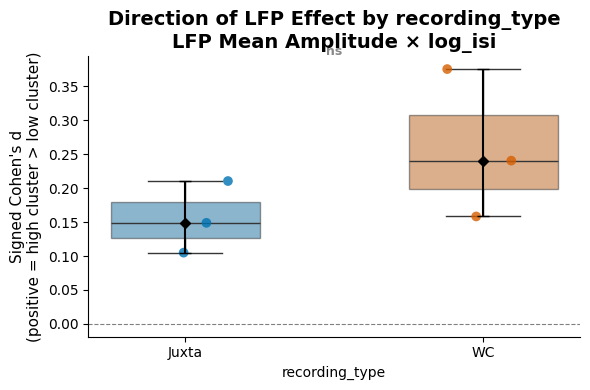

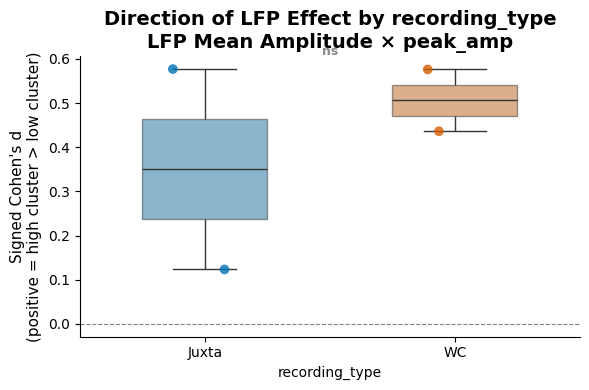

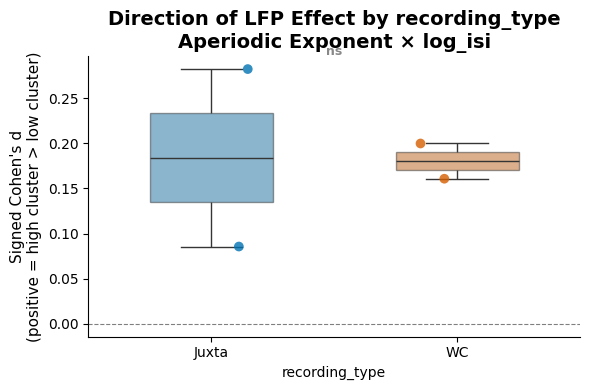

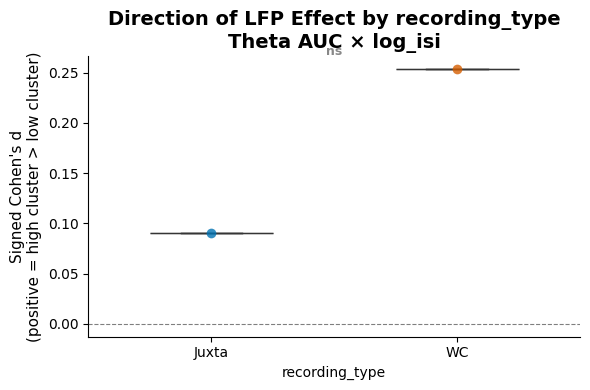

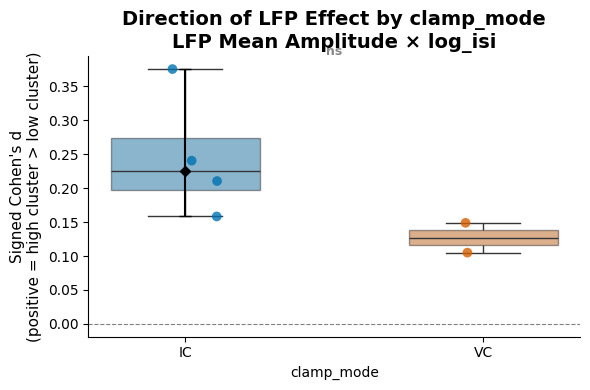

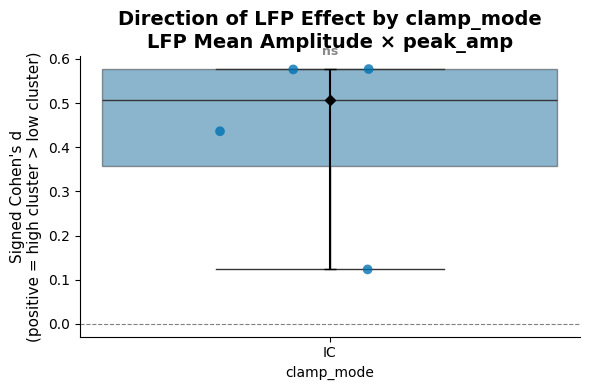

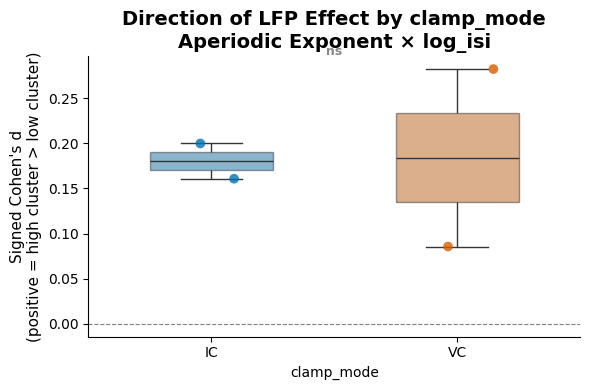

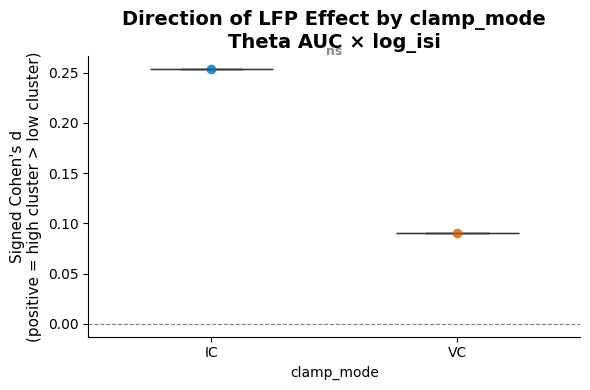

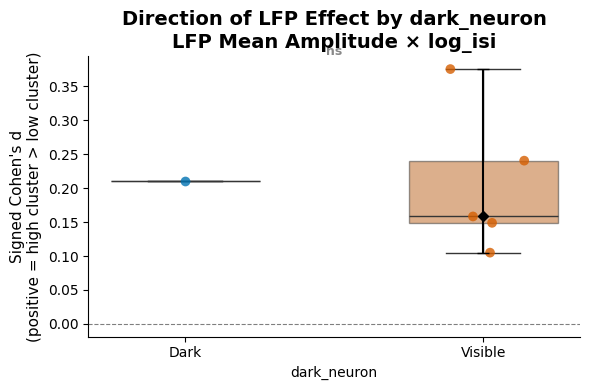

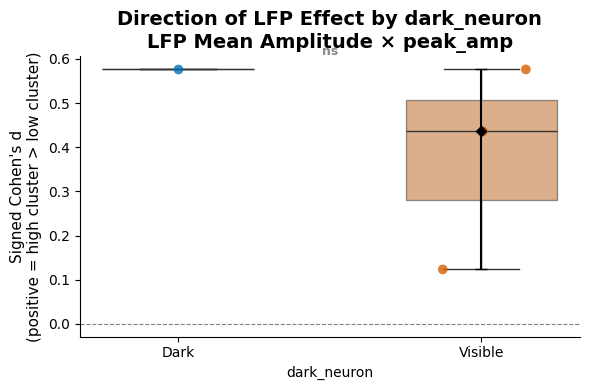

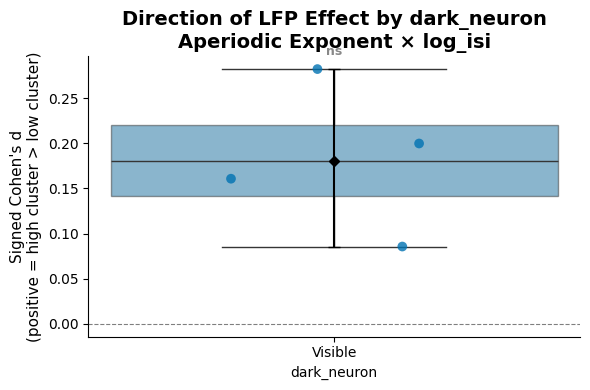

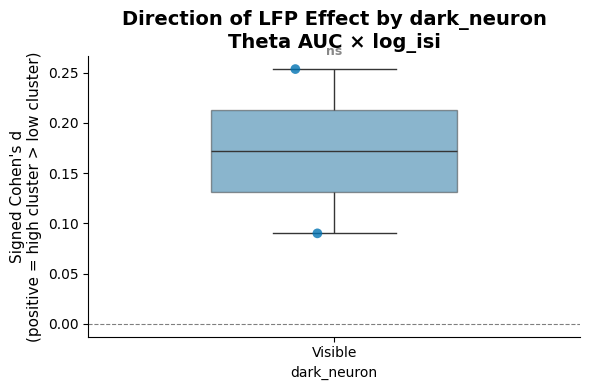

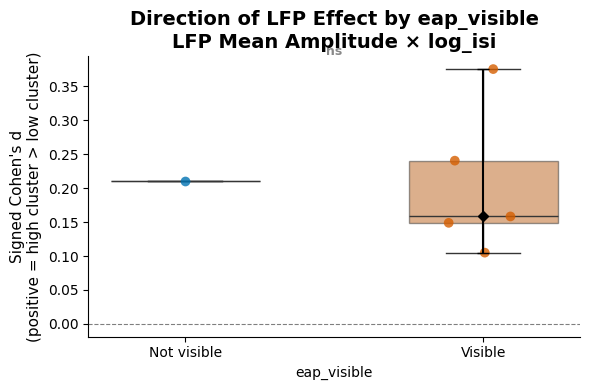

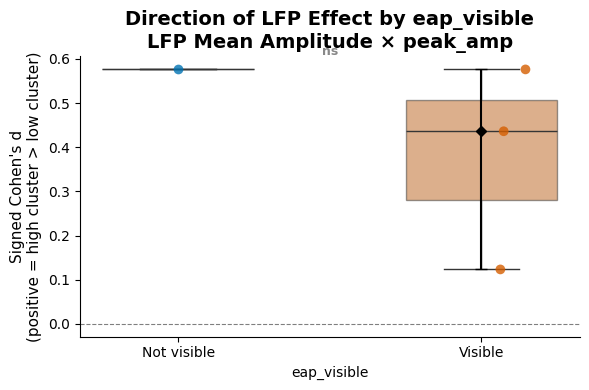

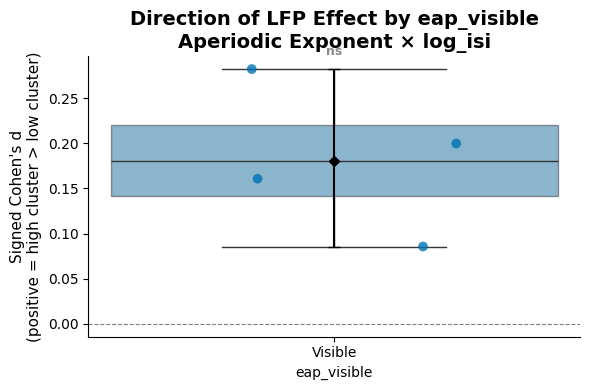

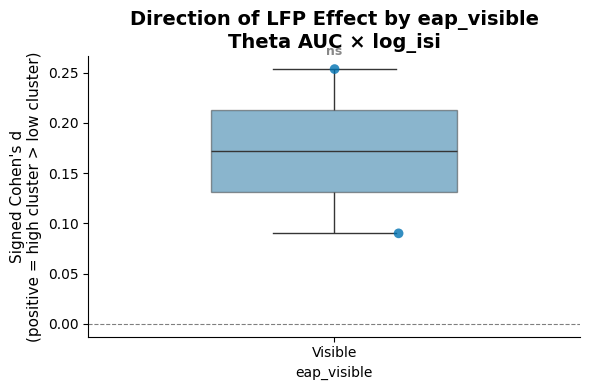


Non-priority cells (n=36)


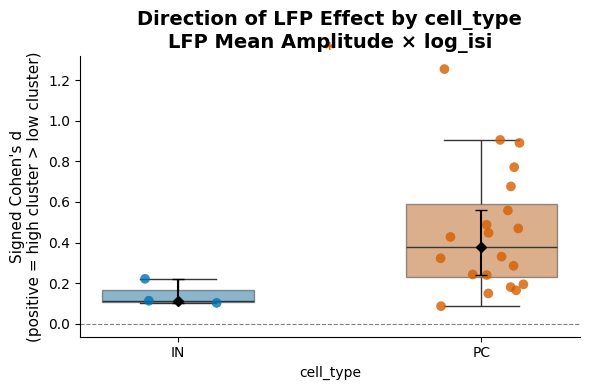

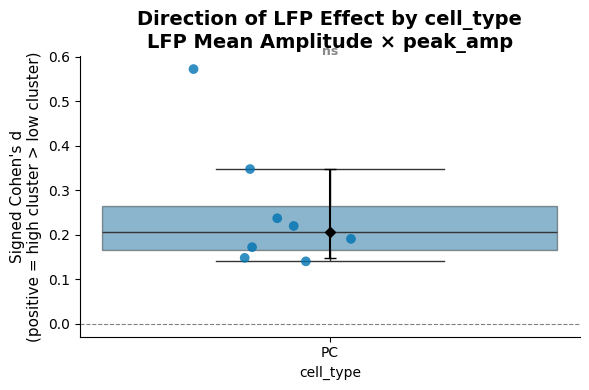

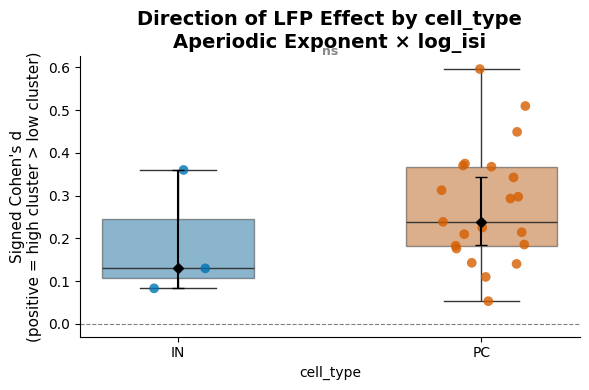

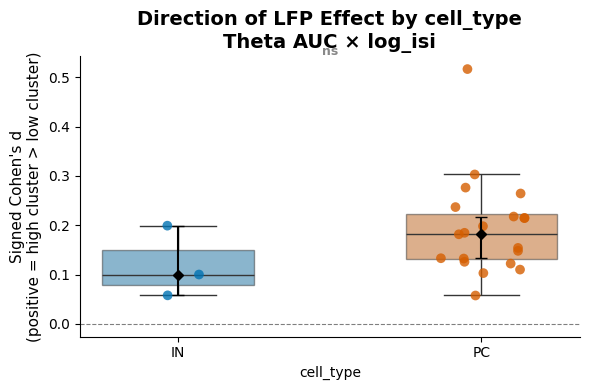

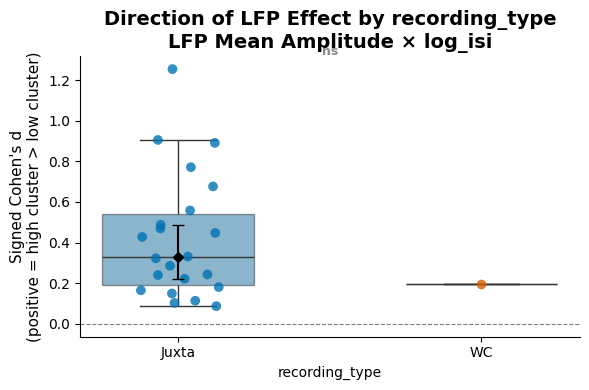

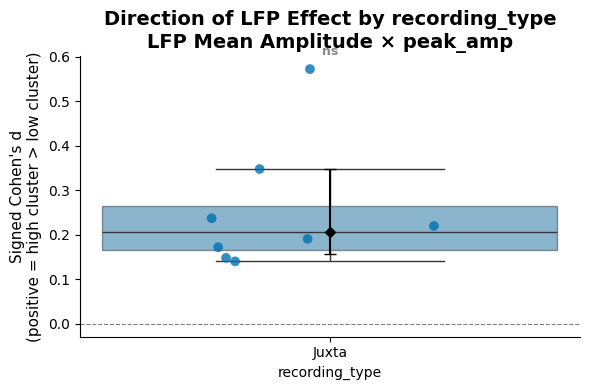

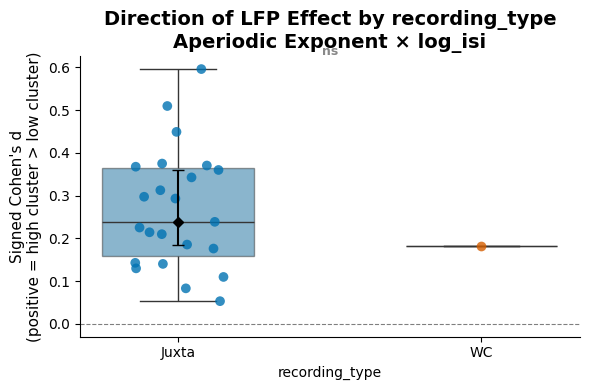

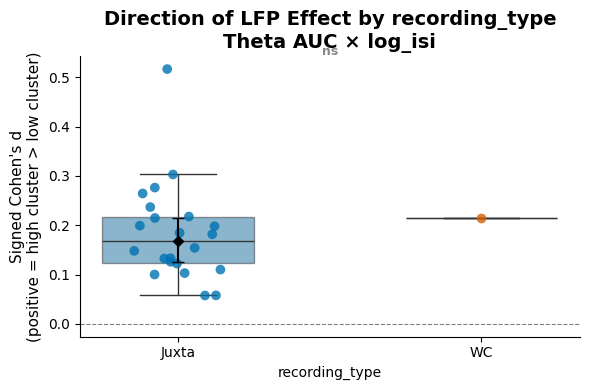

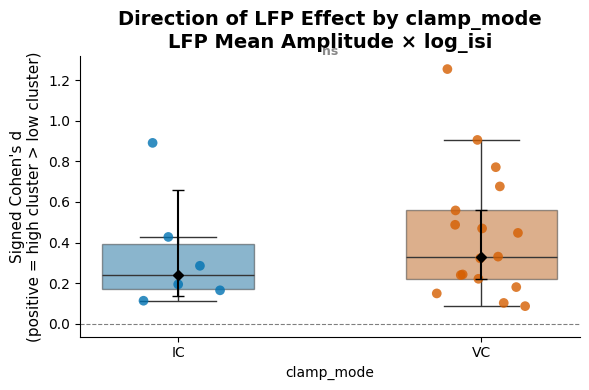

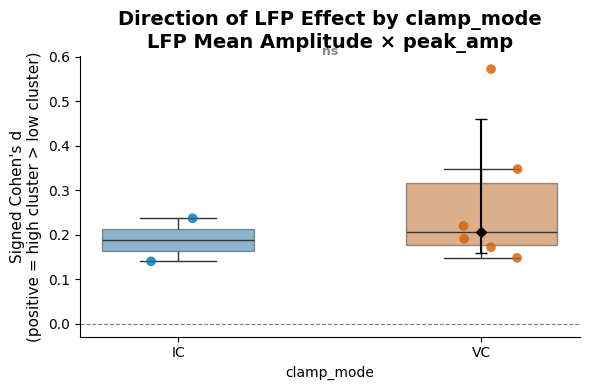

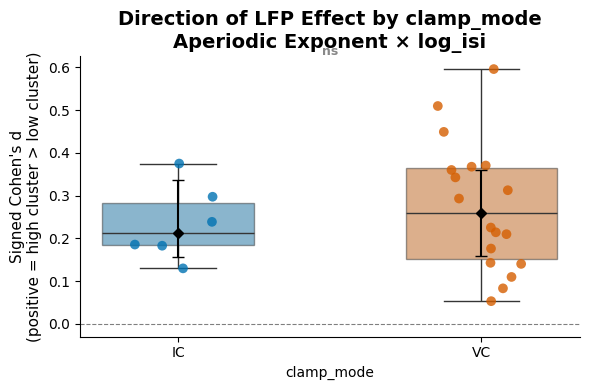

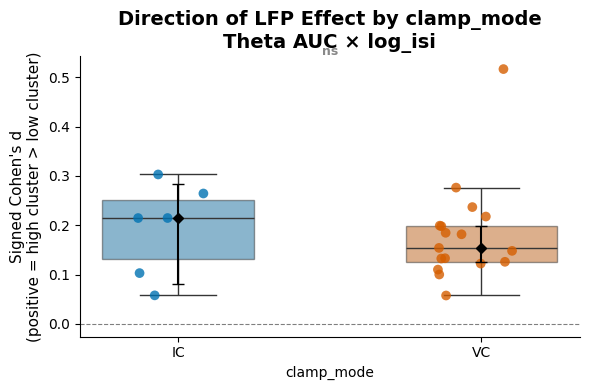

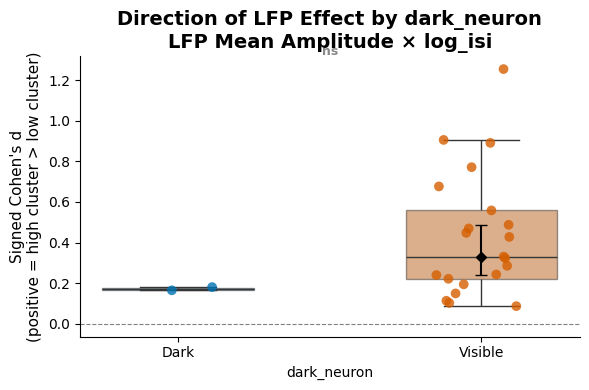

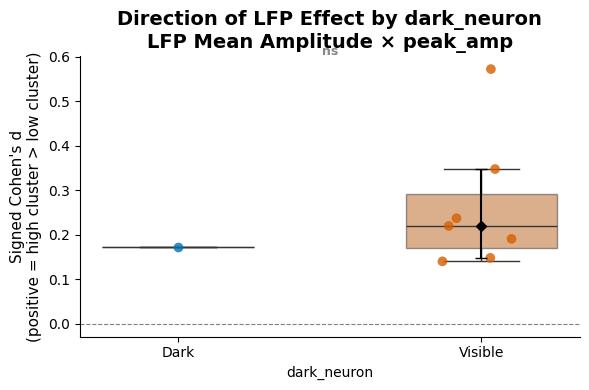

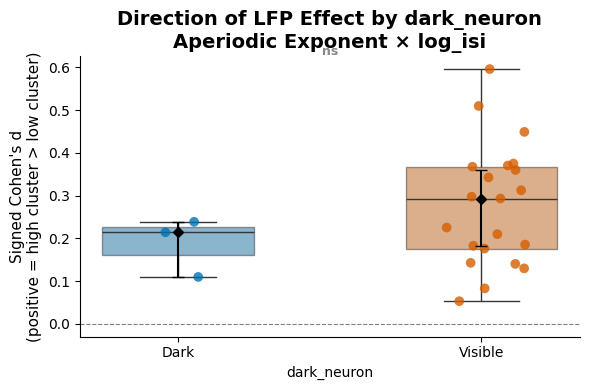

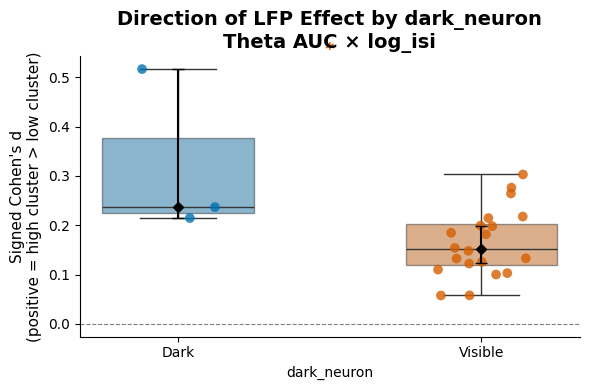

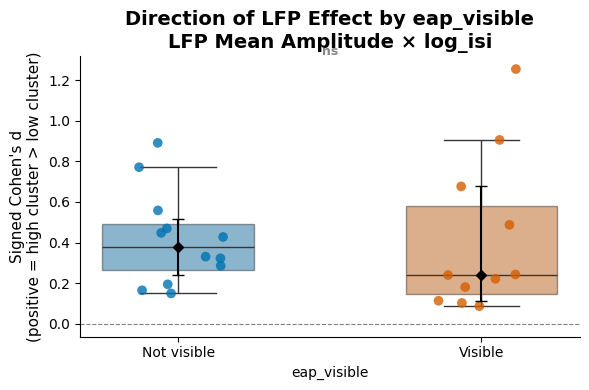

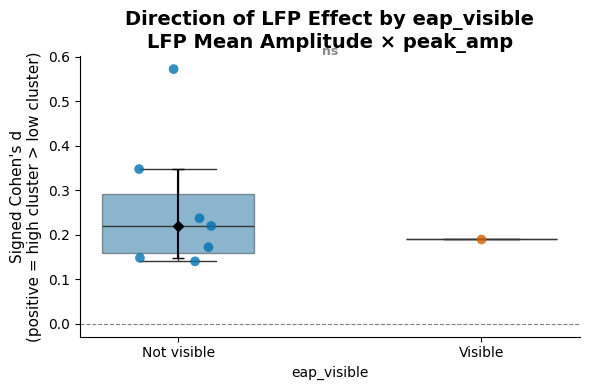

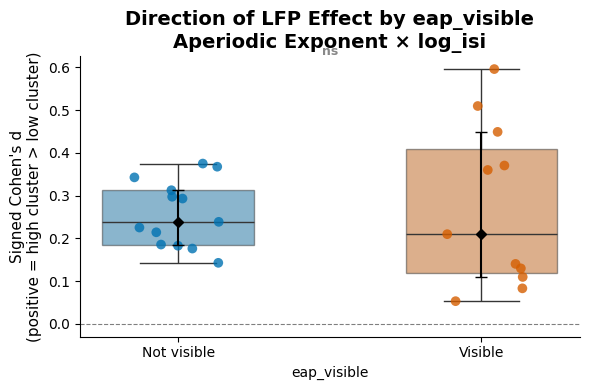

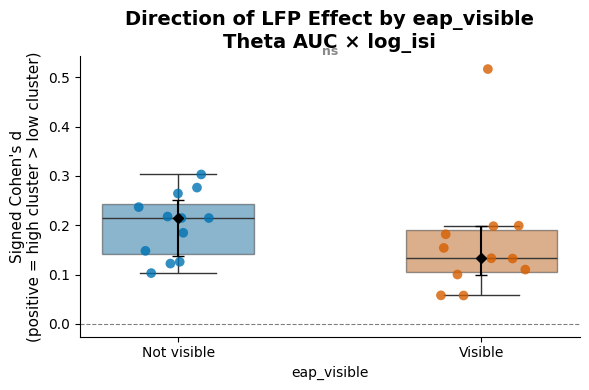


All cells combined (n=43)


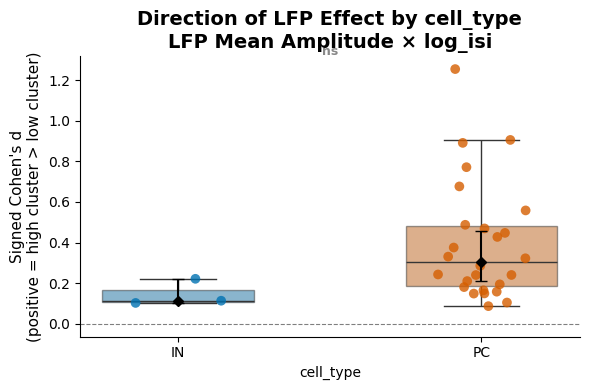

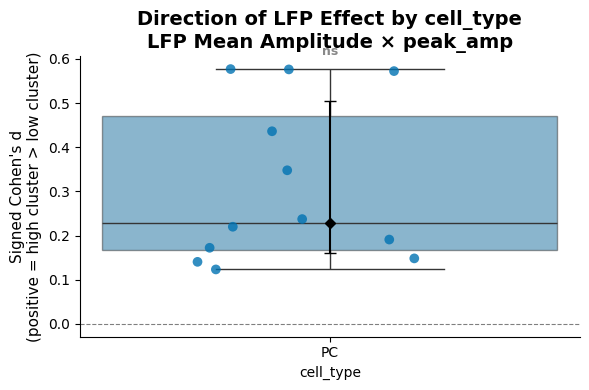

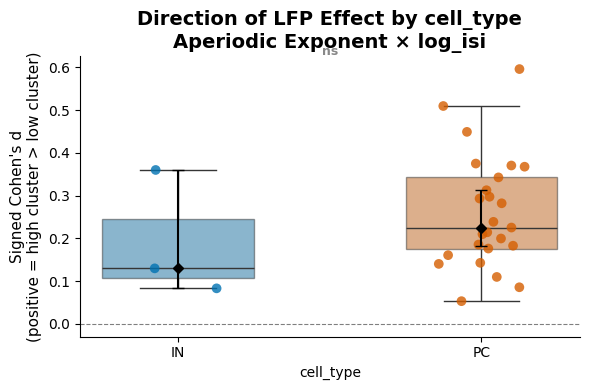

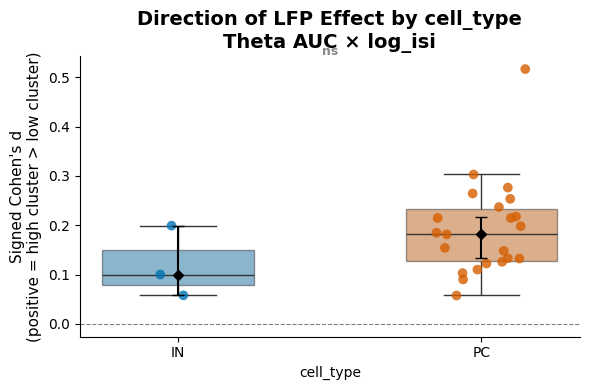

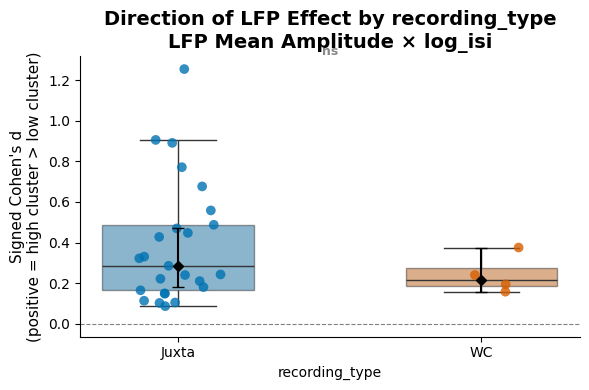

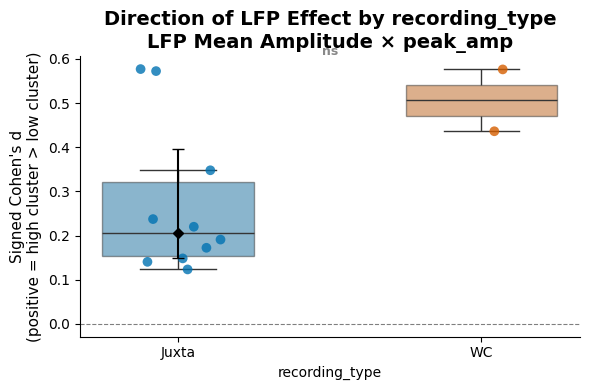

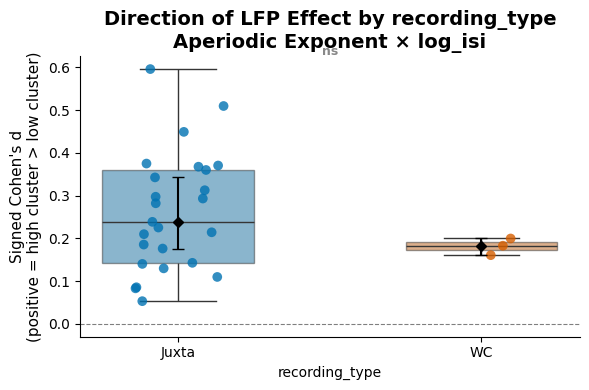

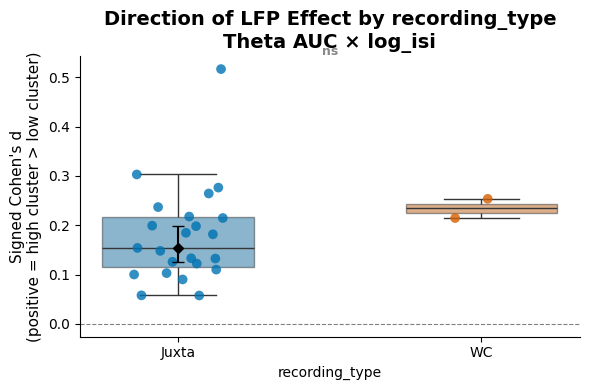

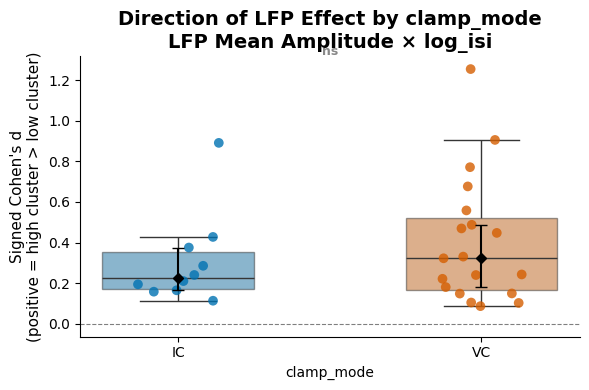

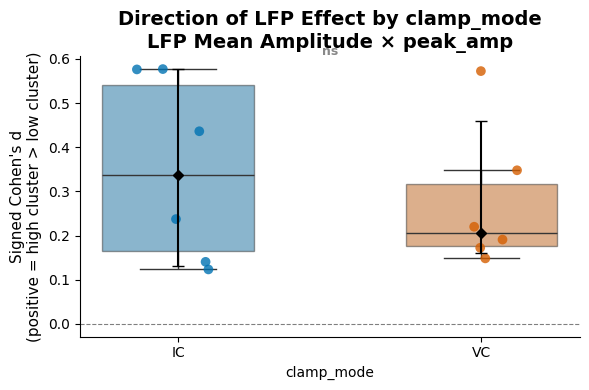

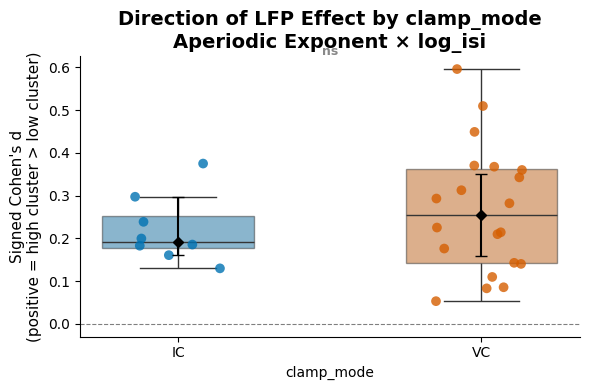

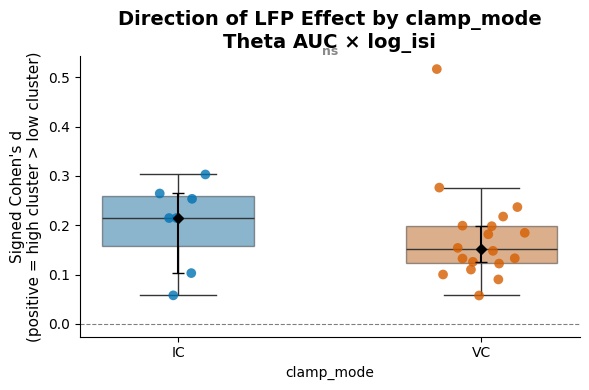

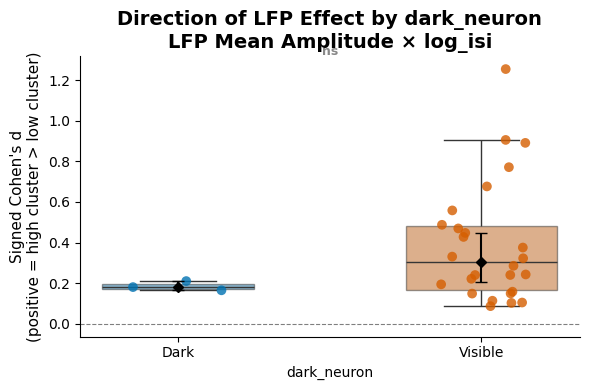

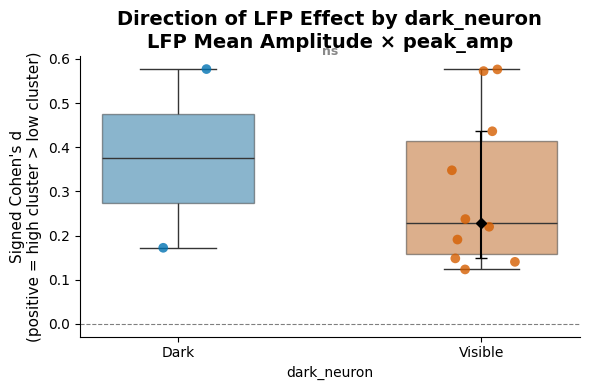

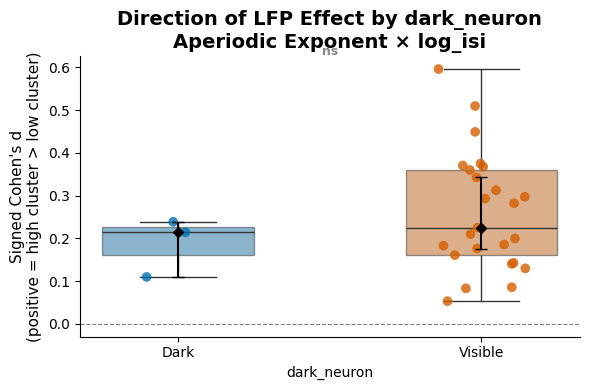

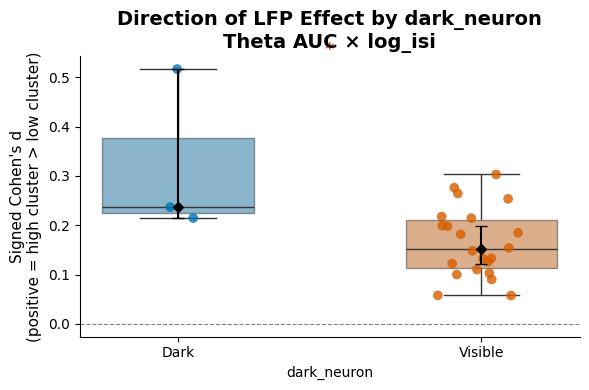

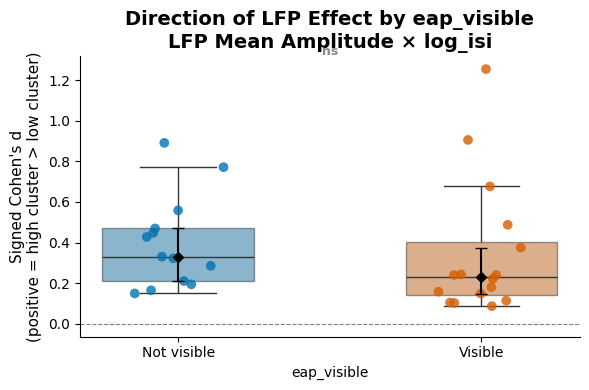

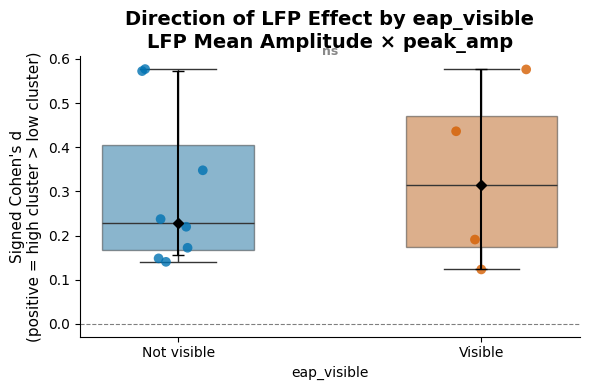

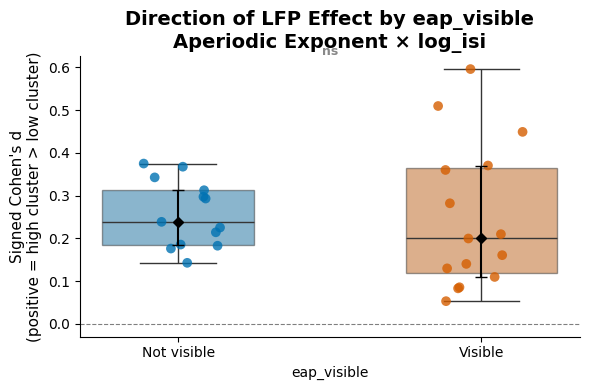

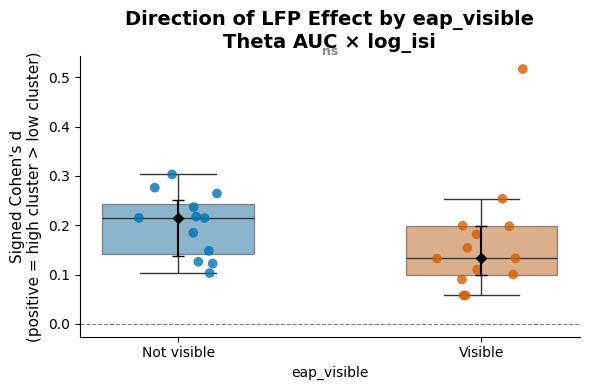

In [6]:
key_combos = [
    ("LFP Mean Amplitude", "log_isi_cluster"),
    ("LFP Mean Amplitude", "peak_amp_cluster"),
    ("Aperiodic Exponent", "log_isi_cluster"),
    ("Theta AUC",          "log_isi_cluster"),
]

for label, cell_ids in SUBSET_LABELS:
    print(f"\n{'='*60}\n{label} (n={len(cell_ids)})\n{'='*60}")
    df_ps = df_pop_stats[df_pop_stats["cell_id"].isin(cell_ids)]
    for cat in CAT_VARS:
        meta_map = (df_meta[df_meta["cell_id"].isin(cell_ids)]
                    .drop_duplicates("cell_id")
                    .set_index("cell_id")[cat]
                    .to_dict())
        for lfp_feat, spk_feat in key_combos:
            plot_lfp_directionality_by_metadata(df_ps, meta_map, lfp_feat, spk_feat, cat)

If one metadata group clusters consistently above zero and another below — that metadata variable explains the directional heterogeneity. If all groups straddle zero, the effect direction is idiosyncratic to individual cells and reflects something we didn't measure — likely intrinsic cellular properties like ion channel composition or metabolic state.

## Does metadata predict the log_ISI × post-spike exponent effect?

The pre/post analysis found log_ISI clusters predict post-spike aperiodic exponent in ~40% of cells. Which cells are those 40%?

Mann-Whitney + bootstrap 95% CI on median difference. Stars/ns always shown.

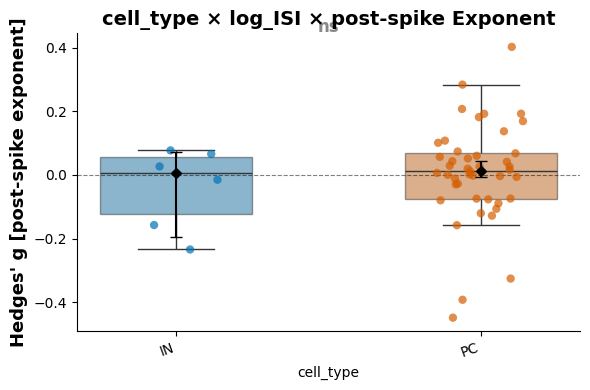

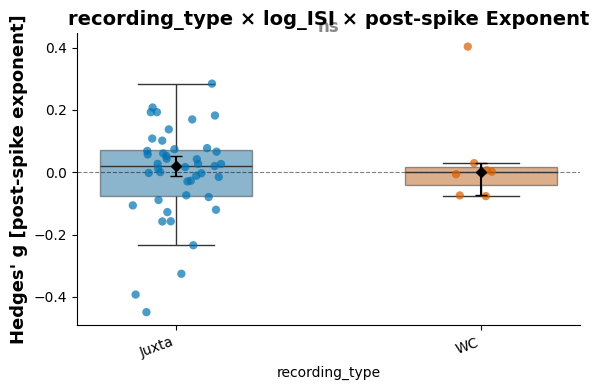

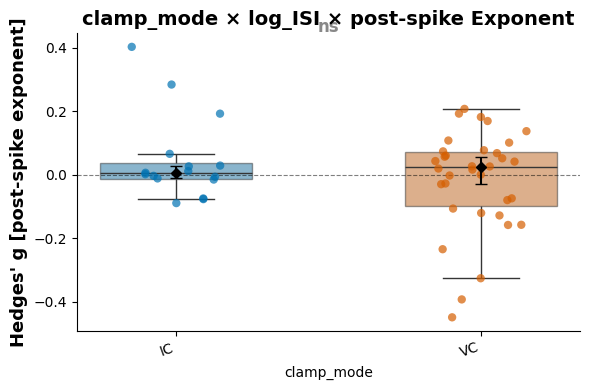

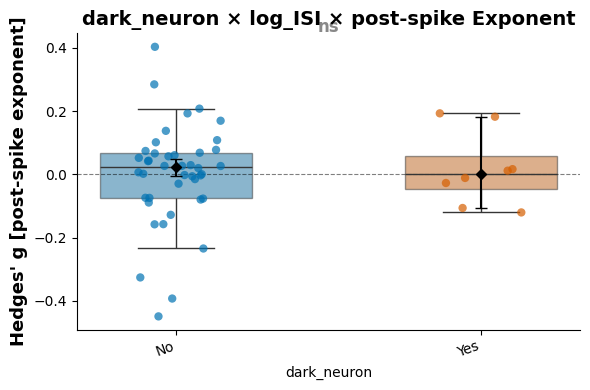

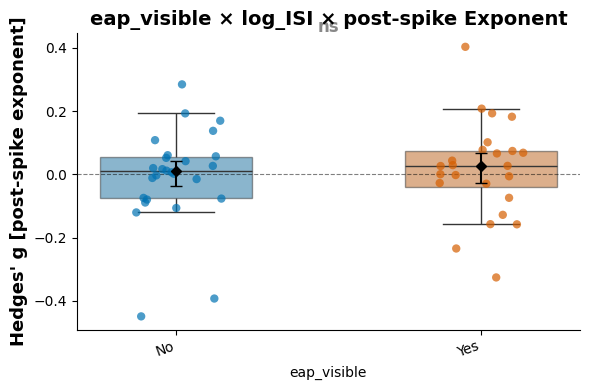

In [7]:
from scipy.stats import mannwhitneyu as _mwu

df_pp = df_prepost[
    (df_prepost["lfp_feature"] == "exponent") &
    (df_prepost["window"] == "post") &
    (df_prepost["spike_feature"].str.contains("log_isi", na=False))
].copy()
df_pp["cell_num"] = df_pp["cell_id"].str.lstrip("c").astype(int)

for cat, meta_dict in [
    ("cell_type",       DICT_CELL_TYPE),
    ("recording_type",  DICT_PATCH_TYPE),
    ("clamp_mode",      DICT_PATCH_TYPE),
    ("dark_neuron",     DICT_DARK_NEURONS),
    ("eap_visible",     DICT_EAP_WAV),
]:
    if cat == "recording_type":
        df_pp[cat] = df_pp["cell_num"].map(meta_dict).str.split(",").str[0].str.strip()
    elif cat == "clamp_mode":
        df_pp[cat] = df_pp["cell_num"].map(meta_dict).str.split(",").str[-1].str.strip()
    elif cat in ("dark_neuron", "eap_visible"):
        lbl = {True: "Yes", False: "No"}
        df_pp[cat] = df_pp["cell_num"].map(meta_dict).map(lbl)
    else:
        df_pp[cat] = df_pp["cell_num"].map(meta_dict)

    d = df_pp.dropna(subset=[cat, "hedges_g"])
    order = sorted(d[cat].unique())
    if len(order) < 2: continue
    colors = [_CB_PALETTE[i % len(_CB_PALETTE)] for i in range(len(order))]

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(data=d, x=cat, y="hedges_g", order=order,
                palette=dict(zip(order, colors)),
                width=0.5, fliersize=0, boxprops={"alpha":0.5}, ax=ax)
    sns.stripplot(data=d, x=cat, y="hedges_g", order=order,
                  palette=dict(zip(order, colors)),
                  alpha=0.7, jitter=0.15, size=6, legend=False, ax=ax)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)

    # Bootstrap CI on medians
    for gi, grp in enumerate(order):
        vals = d[d[cat]==grp]["hedges_g"].dropna().values
        if len(vals) < 3: continue
        boot = [np.median(np.random.choice(vals,len(vals),replace=True)) for _ in range(2000)]
        med = np.median(vals)
        ci_lo, ci_hi = np.percentile(boot,[2.5,97.5])
        ax.errorbar(gi, med, yerr=[[med-ci_lo],[ci_hi-med]],
                    fmt="D", color="black", ms=5, lw=1.5, capsize=4, zorder=5)

    # Test
    if len(order) == 2:
        g1 = d[d[cat]==order[0]]["hedges_g"].dropna()
        g2 = d[d[cat]==order[1]]["hedges_g"].dropna()
        if len(g1)>=3 and len(g2)>=3:
            _, p = _mwu(g1, g2, alternative="two-sided")
            sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
        else: sig = "ns"
    else:
        groups = d.groupby(cat)["hedges_g"].apply(list)
        if all(len(g)>=3 for g in groups.values):
            from scipy.stats import kruskal as _kw
            _, p = _kw(*groups.values)
            sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
        else: sig = "ns"

    y_top = d["hedges_g"].max()
    y_rng = ax.get_ylim()[1] - ax.get_ylim()[0]
    color = _SIG_COL if sig != "ns" else "#888888"
    ax.text(len(order)/2 - 0.5, y_top + 0.05*y_rng, sig,
            ha="center", fontsize=12, fontweight="bold", color=color)

    ax.set_title(f"{cat} × log_ISI × post-spike Exponent", fontsize=_FS_SUB, fontweight="bold")
    ax.set_ylabel("Hedges' g [post-spike exponent]", fontsize=_FS_AX, fontweight="bold")
    ax.set_xticklabels(order, rotation=20, ha="right")
    sns.despine(ax=ax)
    plt.tight_layout(); plt.show()

If one metadata group drives the 40% yield — e.g. only Juxta cells, or only PCs — that tells you the post-spike exponent coupling to ISI history is specific to a recording or cell-type context. If it's mixed across all groups, it's a general phenomenon that affects a subpopulation of cells regardless of their type or how they were recorded.